
# EDA: Локализации модов (Stellaris)

Этот ноутбук — разведочный анализ данных (EDA) для файлов локализаций Paradox/Stellaris (`*.yml`). Для сбора данных был проведен парсинг страницы мастерской стеллариса в стиме - всего есть 34,116 модов, скачано 1,599.
Из каждой модификации извлекались файлы локализации (в случае их наличия).
Далее представлен анализ содержимого файлов


In [75]:
from pathlib import Path
from typing import List, Dict, Any
from tqdm import tqdm
import pandas as pd
import pickle
import re

# Папка с модами
ROOT_DIR = Path("/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod")


RE_LANG_HEADER = re.compile(r"^\s*l_([a-z_]+)\s*:\s*$", re.IGNORECASE)
RE_LANG_IN_FILENAME = re.compile(r"_l_([a-z_]+)\.yml$", re.IGNORECASE)

BASE_LANGS = [
    "english", "russian", "german", "french", "spanish", "polish",
    "italian", "japanese", "korean",
    "simp_chinese", "chinese",
    "portuguese", "braz_por",
    "turkish", "ukrainian",
]

def norm_lang(s: str | None) -> str | None:
    if not s:
        return None
    s = s.lower().strip()

    if s.startswith("l_"):
        s = s[2:]

    if s in BASE_LANGS:
        return s

    for base in BASE_LANGS:
        if base in s:
            return base

    return s

def lang_from_path(path: Path) -> str | None:
    parts = [p.lower() for p in path.parts]
    for part in parts:
        lang_guess = norm_lang(part)
        if lang_guess and lang_guess in BASE_LANGS:
            return lang_guess
    return None

def lang_from_filename(path: Path) -> str | None:
    m = RE_LANG_IN_FILENAME.search(path.name)
    return norm_lang(m.group(1)) if m else None

yml_files = []
for mod_dir in ROOT_DIR.iterdir():
    if not mod_dir.is_dir():
        continue
    loc_dir = mod_dir / "localisation"
    if not loc_dir.exists():
        continue
    for path in loc_dir.rglob("*.yml"):
        yml_files.append({
            "mod_id": mod_dir.name,
            "path": path,
            "relative_path": path.relative_to(ROOT_DIR),
            "hint_path": lang_from_path(path),
            "hint_filename": lang_from_filename(path),
        })

print(f"Найдено файлов локализаций: {len(yml_files)}")
for f in yml_files[:5]:
    print(f["relative_path"], " | hint_path=", f["hint_path"], " | hint_filename=", f["hint_filename"])

Найдено файлов локализаций: 19653
2907704328/localisation/korean/resettlement_tool_l_korean.yml  | hint_path= korean  | hint_filename= korean
2907704328/localisation/simp_chinese/resettlement_tool_l_simp_chinese.yml  | hint_path= simp_chinese  | hint_filename= simp_chinese
2907704328/localisation/japanese/resettlement_tool_l_japanese.yml  | hint_path= japanese  | hint_filename= japanese
2907704328/localisation/german/resettlement_tool_l_german.yml  | hint_path= german  | hint_filename= german
2907704328/localisation/russian/resettlement_tool_l_russian.yml  | hint_path= russian  | hint_filename= russian


## Парсинг и извлечение признаков
### Структурные и синтаксические метрики
Нужны чтобы понять корректен ли синтаксис в файлах, и на сколько сложно будет работать с текстом в этих файлах

#### Кавычки
n_quotes — количество неэкранированных кавычек; проверка корректности открытия/закрытия строки \
has_unclosed_quotes — есть ли незакрытая кавычка; индикатор синтаксической ошибки

#### Скобки: квадратные
n_brackets_square_open — число символов '['; проверка баланса квадратных скобок \
n_brackets_square_close — число символов ']'; проверка баланса квадратных скобок \
is_balanced_square — сбалансированы ли квадратные скобки

#### Скобки: фигурные
n_brackets_curly_open — число '{'; проверка баланса фигурных скобок \
n_brackets_curly_close — число '}'; проверка баланса фигурных скобок \
is_balanced_curly — сбалансированы ли фигурные скобки

#### Скобки: круглые
n_brackets_round_open — число '('; проверка баланса круглых скобок \
n_brackets_round_close — число ')'; проверка баланса круглых скобок \
is_balanced_round — сбалансированы ли круглые скобки

#### Экранированные последовательности
has_escape_sequences — есть ли экранированные последовательности ('\n'; '\t'; '\"'; ) \
n_escape_sequences — общее число экранированных последовательностей;

#### Прочее
has_colon_in_text — есть ли двоеточие в тексте \
has_multiline_continuation — есть ли перенос или литерал '\n'; определяет многострочность строки


In [76]:
groups = {}
structural_keys = [
    # кавычки
    "n_quotes",
    "has_unclosed_quotes",

    # скобки квадратные
    "n_brackets_square_open",
    "n_brackets_square_close",
    "is_balanced_square",

    # скобки фигурные
    "n_brackets_curly_open",
    "n_brackets_curly_close",
    "is_balanced_curly",

    # скобки круглые
    "n_brackets_round_open",
    "n_brackets_round_close",
    "is_balanced_round",
]

syntactic_keys = [
    "has_escape_sequences",
    "n_escape_sequences",
    "has_colon_in_text",
    "has_multiline_continuation",
]

groups.update({k: "structural" for k in structural_keys})
groups.update({k: "syntactic" for k in syntactic_keys})

_RE_ESC_N     = re.compile(r'(?<!\\)\\n')
_RE_ESC_T     = re.compile(r'(?<!\\)\\t')
_RE_ESC_QUOTE = re.compile(r'(?<!\\)\\"')

_RE_BARE_QUOTE = re.compile(r'(?<!\\)"')

#функция для расчета метрик, разбил на разные, чтобы было проще изменять
def struct_syntax_metrics(text: str) -> Dict[str, Any]:
    if text is None:
        text = ""

    n_quotes = len(_RE_BARE_QUOTE.findall(text))
    has_unclosed_quotes = (n_quotes % 2 == 1)

    n_sq_open  = text.count('[')
    n_sq_close = text.count(']')
    n_cu_open  = text.count('{')
    n_cu_close = text.count('}')
    n_ro_open  = text.count('(')
    n_ro_close = text.count(')')

    is_balanced_square = (n_sq_open == n_sq_close)
    is_balanced_curly  = (n_cu_open == n_cu_close)
    is_balanced_round  = (n_ro_open == n_ro_close)

    esc_n     = _RE_ESC_N.findall(text)
    esc_t     = _RE_ESC_T.findall(text)
    esc_quote = _RE_ESC_QUOTE.findall(text)
    n_esc_all = len(esc_n) + len(esc_t) + len(esc_quote)

    has_escape_n     = bool(esc_n)
    has_escape_t     = bool(esc_t)
    has_escape_quote = bool(esc_quote)
    has_escape_sequences = has_escape_n or has_escape_t or has_escape_quote

    has_colon_in_text = (':' in text)

    has_real_newline = ('\n' in text)
    has_literal_n    = bool(_RE_ESC_N.search(text))
    has_multiline_continuation = has_real_newline or has_literal_n

    return {
        # Кавычки
        "n_quotes": n_quotes,
        "has_unclosed_quotes": has_unclosed_quotes,

        # Скобки: квадратные
        "n_brackets_square_open": n_sq_open,
        "n_brackets_square_close": n_sq_close,
        "is_balanced_square": is_balanced_square,

        # Скобки: фигурные
        "n_brackets_curly_open": n_cu_open,
        "n_brackets_curly_close": n_cu_close,
        "is_balanced_curly": is_balanced_curly,

        # Скобки: круглые
        "n_brackets_round_open": n_ro_open,
        "n_brackets_round_close": n_ro_close,
        "is_balanced_round": is_balanced_round,

        # Экранированные последовательности
        "has_escape_sequences": has_escape_sequences,
        "n_escape_sequences": n_esc_all,

        # Прочее
        "has_colon_in_text": has_colon_in_text,
        "has_multiline_continuation": has_multiline_continuation,
    }

### Семантические/лингвистические метрики
Чуть более сложный анализ содержимого - поможет определить на сколько много будет проблем при загрузке всего в переводчик
#### Токен/регистр
n_uppercase_tokens — сколько «слов» целиком в ВЕРХНЕМ регистре \
n_camelcase_tokens — сколько Camel/PascalCase токенов

#### Числа и множители
has_numeric_token — есть ли токены с цифрами/математикой

#### Пунктуация и сегментация
n_sentences — оценка количества предложений (. ! ? …)

#### Длина/объём
len_chars — общая длина строки в символах

In [77]:
semantic_keys = [
    "n_uppercase_tokens",
    "n_camelcase_tokens",
    "has_numeric_token",
    "n_sentences",
    "len_chars",
]

groups.update({k: "semantic" for k in semantic_keys})

_TOKEN_RE = re.compile(r"[A-Za-zА-Яа-яЁё0-9]+(?:['’-][A-Za-zА-Яа-яЁё0-9]+)*")


_SENT_END_RE = re.compile(r"(?:\.\s|!\s|\?\s|…\s|[.!?…]$)")

def _is_uppercase_token(tok: str) -> bool:
    letters = [ch for ch in tok if ch.isalpha()]
    return bool(letters) and all(ch.upper() == ch and ch.lower() != ch for ch in letters)

def _is_camelcase_token(tok: str) -> bool:
    letters = [ch for ch in tok if ch.isalpha()]
    if not letters:
        return False
    has_upper = any(ch.isupper() for ch in letters)
    has_lower = any(ch.islower() for ch in letters)
    return has_upper and has_lower

_MATH_PATTERNS = [
    re.compile(r"\d+(?:\.\d+)?\s*%"),

    re.compile(r"(?<!\w)\d+(?:\.\d+)?[eE][+\-]?\d+(?!\w)"),

    re.compile(r"\b\d+\s*[/:⁄]\s*\d+\b"),

    re.compile(r"[½⅓⅔¼¾⅛⅜⅝⅞]"),

    re.compile(r"(?:\d|\b[A-Za-z])\s*[+\-−±*/×·∙÷:^=<>≤≥≠≈~]\s*(?:\d|\b[A-Za-z])"),

    re.compile(r"(?:(?<!\w)\d+(?:\.\d+)?[A-Za-z]|[A-Za-z]\d+(?!\w))"),
    re.compile(r"[A-Za-z](?:\^\d+|[₀-₉]+|[⁰¹²³⁴⁵⁶⁷⁸⁹]+)"),

    re.compile(r"\b\d+(?:\.\d+)?\s*[–—-]\s*\d+(?:\.\d+)?\b"),

    re.compile(r"\((?:[^()]*\d[^()]*)\)"),
]

_TRANSLATE = str.maketrans({
    "−": "-",
    "—": "-",
    "–": "-",
    "×": "*",
    "·": "*",
    "∙": "*",
    "÷": "/",
    "⁄": "/",
    "±": "+",
})

def _has_numeric_token(tokens) -> bool:
    for t in tokens:
        if not t:
            continue
        s = str(t).strip()
        if not s:
            continue

        s_norm = s.translate(_TRANSLATE)

        for pat in _MATH_PATTERNS:
            if pat.search(s) or pat.search(s_norm):
                return True

    return False

def semantic_linguistic_metrics(text: str) -> Dict[str, Any]:
    if text is None:
        text = ""

    tokens = _TOKEN_RE.findall(text)

    n_uppercase = sum(1 for t in tokens if _is_uppercase_token(t))
    n_camelcase = sum(1 for t in tokens if _is_camelcase_token(t))
    has_numeric = _has_numeric_token(tokens)

    # счёт предложений — по окончаниям;
    n_sents = len(_SENT_END_RE.findall(text))


    return {
        "n_uppercase_tokens": n_uppercase,
        "n_camelcase_tokens": n_camelcase,
        "has_numeric_token": has_numeric,
        "n_sentences": n_sents,
        "len_chars": len(text),
    }



### Доменные (игровые) токены
#### Основные доменные токены Stellaris - не подлежат переводу
n_pound_icons — количество иконок £icon£ \
n_dollar_vars — количество переменных \$token\$ \
n_get_tokens — количество конструкций \[Root.Owner.GetAdj\] \
n_scripted_loc_calls — общее число скриптовых локализационных вызовов

#### Форматирование и числовые данные
has_color_code — флаг наличия §X или §! \
has_inline_math — флаг наличия чисел/процентов (+10, -5, 0.4%)  \
is_placeholder_only — в строке просто плейсхолдер

In [78]:
import re
from typing import Dict, Any

domain_keys = [
    "n_pound_icons",
    "n_dollar_vars",
    "n_get_tokens",
    "n_scripted_loc_calls",
    "has_color_code",
    "has_inline_math",
    "is_placeholder_only",
]

groups.update({k: "domain" for k in domain_keys})

# базовые доменные паттерны
RE_GET_TOKEN = re.compile(
    r"\[(?:\?[A-Za-z0-9_:.]+(?:\|[A-Za-z0-9%+\-_.]+)*|[A-Za-z0-9_]+(?:\.[A-Za-z0-9_]+)*(?:\([^()\[\]]*\))?(?:\|[A-Za-z0-9%+\-_.]+)*|[A-Za-z0-9_]+_i)\]"
)  # [Root.Owner.GetAdj]
RE_COLOR_CODE       = re.compile(r"§[A-Za-z0-9!]")                           # §R, §!
RE_INLINE_MATH      = re.compile(r"(?<!\w)[+\-]?\d+(?:\.\d+)?%?")            # +10, -5, 0.4%
RE_SCRIPT_AT        = re.compile(r"(?<!\S)@[A-Za-z0-9_]+")                   # начало слова: @foo
RE_DOLLAR_VAR       = re.compile(r"\$[A-Za-z0-9_.]+\$")                      # $job_plural$
RE_NON_WHITESPACE   = re.compile(r"\S")
RE_POUND_ICON       = re.compile(r"£[A-Za-z0-9_]+£")                         # £amenities£
RE_BRACES           = re.compile(r"\{[^}]*\}")                               # {something}
RE_PRINTF           = re.compile(r"%[sdif]")                                 # %s %d %i %f
RE_TREE_MARKS     = re.compile(r"[>\u2013\u2014\-•]+")  # >, –, —, -,
RE_BRACKET_NUMBER = re.compile(r"\[\d+\]")              # [1], [23], ...

def domain_token_metrics(text: str | None) -> Dict[str, Any]:
    if not text:
        text = ""

    pound_icons = RE_POUND_ICON.findall(text)
    dollar_vars = RE_DOLLAR_VAR.findall(text)
    get_tokens  = RE_GET_TOKEN.findall(text)
    at_calls    = RE_SCRIPT_AT.findall(text)

    n_scripted  = len(at_calls)

    has_color   = RE_COLOR_CODE.search(text) is not None

    inline_math = RE_INLINE_MATH.findall(text)
    has_math    = bool(inline_math)

    # очищаем текст от всех плейсхолдеров, чтобы понять, остался ли «голый» текст
    tmp = text
    for regex in (
        RE_POUND_ICON,
        RE_DOLLAR_VAR,
        RE_GET_TOKEN,
        RE_SCRIPT_AT,
        RE_COLOR_CODE,
        RE_INLINE_MATH,
        RE_BRACES,
        RE_PRINTF,
    ):
        tmp = regex.sub("", tmp)

    # если после очистки остались только пробелы/переводы строк
    tmp = RE_BRACKET_NUMBER.sub("", tmp)           # [1], [23]
    tmp = RE_TREE_MARKS.sub("", tmp)               # > --- •
    tmp = tmp.strip()

    is_placeholder_only = re.search(r"[^\W\d_]", tmp, flags=re.UNICODE) is None

    return {
        "n_pound_icons": len(pound_icons),
        "n_dollar_vars": len(dollar_vars),
        "n_get_tokens": len(get_tokens),
        "n_scripted_loc_calls": n_scripted,
        "has_color_code": has_color,
        "has_inline_math": has_math,
        "is_placeholder_only": is_placeholder_only,
    }

### Маркапные метрики
#### То что нужно для синтеза похожего датасета
placeholders_ratio — доля плейсхолдеров относительно длины строки \
non_alpha_ratio — доля небуквенных символов \
n_protected_tokens — сколько элементов нужно «защитить» при машинном переводе \
entropy_chars — энтропия символов; индикатор разнообразия символов \
placeholder_depth — максимальная глубина плейсхолдеров

In [79]:
import re
import math
from typing import Dict, Any

translation_keys = [
    "placeholders_ratio",
    "non_alpha_ratio",
    "n_protected_tokens",
    "entropy_chars",
    "placeholder_depth",
]

groups.update({k: "translation" for k in translation_keys})


def _entropy_chars(s: str) -> float:
    if not s:
        return 0.0
    from collections import Counter
    total = len(s)
    cnt = Counter(s)
    return -sum((c / total) * math.log2(c / total) for c in cnt.values())


def placeholder_depth(text: str) -> int:
    if not text:
        return 0

    i = 0
    n = len(text)
    max_depth = 0
    stack = []

    def at_depth() -> int:
        return 1 + len(stack)

    while i < n:
        if text[i] == "§" and i + 1 < n and text[i + 1] == "!":
            if stack and stack[-1] == "color":
                stack.pop()
            i += 2
            continue

        if text[i] == "§" and i + 1 < n and text[i + 1] != "!":
            stack.append("color")
            max_depth = max(max_depth, at_depth())
            i += 2
            continue

        if text[i] == "$":
            j = text.find("$", i + 1)
            if j != -1:
                inner = text[i + 1 : j]
                stack.append("dollar")
                inner_depth = placeholder_depth(inner)
                max_depth = max(max_depth, len(stack) + inner_depth)
                stack.pop()
                i = j + 1
                continue
            else:
                i += 1
                continue

        m = RE_GET_TOKEN.match(text, i)
        if m:
            max_depth = max(max_depth, at_depth())
            i = m.end()
            continue

        m = RE_SCRIPT_AT.match(text, i)
        if m:
            max_depth = max(max_depth, at_depth())
            i = m.end()
            continue

        m = RE_DOLLAR_VAR.match(text, i)
        if m:
            max_depth = max(max_depth, at_depth())
            i = m.end()
            continue

        m = RE_INLINE_MATH.match(text, i)
        if m:
            max_depth = max(max_depth, at_depth())
            i = m.end()
            continue

        i += 1

    return max_depth


def translation_metrics(text: str | None) -> Dict[str, Any]:
    if text is None:
        text = ""

    # защищаемые плейсхолдеры
    dollar_matches = list(RE_DOLLAR_VAR.finditer(text))
    get_matches    = list(RE_GET_TOKEN.finditer(text))
    icon_matches   = list(RE_POUND_ICON.finditer(text))
    brace_matches  = list(RE_BRACES.finditer(text))
    printf_matches = list(RE_PRINTF.finditer(text))

    n_protected = (
        len(dollar_matches)
        + len(get_matches)
        + len(icon_matches)
        + len(brace_matches)
        + len(printf_matches)
    )

    L = len(text)

    # доля не-буквенных символов
    alpha = sum(1 for ch in text if ch.isalpha())
    non_alpha_ratio = 1.0 - (alpha / L) if L else 0.0

    # доля символов, занятых плейсхолдерами
    covered = set()
    for m in (
        dollar_matches
        + get_matches
        + icon_matches
        + brace_matches
        + printf_matches
    ):
        covered.update(range(m.start(), m.end()))
    placeholders_ratio = (len(covered) / L) if L else 0.0

    # энтропия символов
    ent = _entropy_chars(text)

    return {
        "placeholders_ratio": placeholders_ratio,
        "non_alpha_ratio": non_alpha_ratio,
        "n_protected_tokens": n_protected,
        "entropy_chars": ent,
        "placeholder_depth": placeholder_depth(text),
    }



### Готовим парсер для побитых жизнью файлов

In [80]:
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple
import re
from ruamel.yaml import YAML
from ruamel.yaml.error import YAMLError

meta_keys = [
    "file",
    "line_no",
    "language",
    "key",
    "text",
]

error_keys = [
    "raw_unparsed",
    "struct_error",
    "error_reason",
    "yaml_error",
]

groups.update({k: "meta" for k in meta_keys})
groups.update({k: "errors" for k in error_keys})

_YAML = YAML(typ="safe")

RE_ENTRY = re.compile(r'^\s*([^\s:#][^:]*?)\s*:\s*(.*)$')
RE_LANG = re.compile(r'(?:^|_)l_([a-z0-9_]+)\.yml$', re.IGNORECASE)
RE_BLOCK_HDR = re.compile(r'^[|>][+-]?\d*\s*$')


def norm_lang(s: str) -> str:
    return s.lower()


def infer_lang_from_path(path: Path) -> Optional[str]:
    m = RE_LANG.search(path.name)
    return m.group(1).lower() if m else None


def _strip_inline_comment(s: str) -> str:
    out, in_single, in_double, esc = [], False, False, False
    for ch in s:
        if esc:
            out.append(ch); esc = False; continue
        if ch == '\\':
            out.append(ch); esc = True; continue
        if ch == "'" and not in_double:
            in_single = not in_single; out.append(ch); continue
        if ch == '"' and not in_single:
            in_double = not in_double; out.append(ch); continue
        if ch == '#' and not in_single and not in_double:
            break
        out.append(ch)
    return ''.join(out).rstrip()


def _is_block_scalar_header(s: str) -> bool:
    return bool(RE_BLOCK_HDR.match(s.strip()))


def _starts_quoted(s: str) -> bool:
    s = s.lstrip()
    return s.startswith('"') or s.startswith("'")


def _starts_flow(s: str) -> bool:
    s = s.lstrip()
    return s.startswith('[') or s.startswith('{')


def _looks_like_new_key(line: str, base_indent: int) -> bool:
    if not line.strip():
        return False
    indent = len(line) - len(line.lstrip(' '))
    if indent > base_indent:
        return False
    return RE_ENTRY.match(line) is not None


def _gather_indented_block(lines: List[str], i: int, base_indent: int) -> Tuple[str, int]:
    n, acc = len(lines), []
    while i < n:
        nxt_raw = lines[i].rstrip("\r\n")
        if _looks_like_new_key(nxt_raw, base_indent):
            break
        if not nxt_raw.strip():
            acc.append(nxt_raw); i += 1; continue
        nxt_indent = len(nxt_raw) - len(nxt_raw.lstrip(' '))
        if nxt_indent > base_indent:
            acc.append(nxt_raw); i += 1; continue
        break
    return "\n".join(acc), i


def _try_yaml_pair_parse(key: str, value_src: str) -> Tuple[bool, Any, Optional[Exception]]:
    doc = f"{key}: {value_src}\n"
    try:
        obj = _YAML.load(doc)
        if isinstance(obj, dict) and key in obj:
            return True, obj[key], None
        return False, None, None
    except YAMLError as e:
        return False, None, e
    except Exception as e:
        return False, None, e

_SPURIOUS_ZERO_BEFORE_QUOTE = re.compile(r'^\s*0+(?=\s*["\'])')

def _fix_spurious_zero_before_quote(s: str) -> str:
    return _SPURIOUS_ZERO_BEFORE_QUOTE.sub('', s)

def preprocess_stellaris_yml_text(text: str) -> str:
    text = re.sub(
        r'^(\s*\S+):\s*\d+(?=\s*["\'])',
        r'\1:',
        text,
        flags=re.M
    )

    text = re.sub(
        r'(?m)^(\s*\S+):\s*\n\s+(["\'])',
        r'\1: \2',
        text
    )

    text = text.lstrip('\ufeff').replace('\r', '')

    return text

#по сути я просто пытаюсь максимально высосать корректные строки из файла
def parse_yml_lines(path: Path, language: Optional[str] = None) -> List[Dict[str, Any]]:
    rows: List[Dict[str, Any]] = []
    lang = norm_lang(language or infer_lang_from_path(path) or "unknown")

    raw_text = path.read_text(encoding="utf-8", errors="replace")


    cleaned_text = preprocess_stellaris_yml_text(raw_text)

    lines = cleaned_text.splitlines(True)


    i, n = 0, len(lines)
    while i < n:
        raw = lines[i].rstrip("\r\n")
        line_no = i + 1
        i += 1

        if not raw.strip() or raw.lstrip().startswith('#'):
            continue

        m = RE_ENTRY.match(raw)
        if not m:
            ok_val, parsed_val, err_val = _try_yaml_pair_parse("_", "\n" + raw)
            rows.append({
                "file": str(path),
                "line_no": line_no,
                "language": lang,
                "key": None,
                "text": parsed_val if ok_val else raw,
                "raw_unparsed": not ok_val,
                "struct_error": True,
                "error_reason": None if ok_val else "yaml_syntax_or_no_key",
                "yaml_error": None if ok_val else (str(err_val) if err_val else "YAML parse error"),
            })
            continue

        key, value_part = m.group(1), m.group(2)
        base_indent = len(raw) - len(raw.lstrip(' '))
        value_clean = _strip_inline_comment(value_part)
        value_src = _fix_spurious_zero_before_quote(value_clean)

        ok_single, parsed_single, err_single = _try_yaml_pair_parse(key, value_src)
        if ok_single:
            rows.append({
                "file": str(path),
                "line_no": line_no,
                "language": lang,
                "key": key,
                "text": parsed_single,
                "raw_unparsed": False,
                "struct_error": False,
            })
            continue

        if _is_block_scalar_header(value_src):
            block_text, i = _gather_indented_block(lines, i, base_indent)
            value_src_full = value_src.strip() + ("\n" + block_text if block_text else "\n")
            ok, parsed, err = _try_yaml_pair_parse(key, value_src_full)
            rows.append({
                "file": str(path),
                "line_no": line_no,
                "language": lang,
                "key": key,
                "text": parsed if ok else value_src_full,
                "raw_unparsed": not ok,
                "struct_error": not ok,
                "error_reason": None if ok else "yaml_syntax",
                "yaml_error": None if ok else (str(err) if err else None),
            })
            continue

        if _starts_quoted(value_src) or _starts_flow(value_src):
            block_text, i2 = _gather_indented_block(lines, i, base_indent)
            joined = value_src if not block_text else value_src + "\n" + block_text
            ok, parsed, err = _try_yaml_pair_parse(key, joined)
            i = i2
            rows.append({
                "file": str(path),
                "line_no": line_no,
                "language": lang,
                "key": key,
                "text": parsed if ok else joined,
                "raw_unparsed": not ok,
                "struct_error": not ok,
                "error_reason": None if ok else "yaml_syntax",
                "yaml_error": None if ok else (str(err) if err else None),
            })
            continue

        block_text, i2 = _gather_indented_block(lines, i, base_indent)
        joined = value_src if not block_text else value_src + "\n" + block_text
        ok, parsed, err = _try_yaml_pair_parse(key, joined)
        i = i2
        rows.append({
            "file": str(path),
            "line_no": line_no,
            "language": lang,
            "key": key,
            "text": parsed if ok else joined,
            "raw_unparsed": not ok,
            "struct_error": not ok,
            "error_reason": None if ok else "yaml_syntax",
            "yaml_error": None if ok else (str(err) if err else None),
        })

    return rows


In [81]:

from pathlib import Path
from ruamel.yaml import YAML
yaml_ru = YAML(typ="safe")

def replace_newlines_outside_quotes(text: str) -> str:

    parts = re.split(r'(".*?"|\'.*?\')', text)
    for i, part in enumerate(parts):
        if not (part.startswith('"') or part.startswith("'")):
            parts[i] = part.replace(r'\n', '\n')
    return ''.join(parts)

def parse_yml_full(path: Path) -> list[dict] | None:
    try:
        text = path.read_text(encoding="utf-8-sig", errors="replace")
        text = re.sub(
            r'^(\s*\S+):[\s\u00A0]*\d+([\s\u00A0]*["\'])',
            r'\1:\2',
            text,
            flags=re.M
        ) #это стеллариосвская фича для переводчиков, для парсинга будет мешаться (по сути ямл парадоксов не является валидным при использовании всех возможностей)
        text = re.sub(r':\s*\n\s*(["\'])', r': \1', text)
        #text = replace_newlines_outside_quotes(text)
        text = re.sub(
            r'(?m)^(\S+):\s*\n\s+(["\'])',
            r'\1: \2',
            text
        )
        doc = yaml_ru.load(text)

        if not isinstance(doc, dict):
            return None

        rows: list[dict] = []
        for lang_key, inner in doc.items():
            lang = norm_lang(lang_key)

            if not isinstance(inner, dict):
                continue

            for key, value in inner.items():
                if isinstance(value, (str, int, float, bool)) or value is None:
                    rows.append({
                        "file": str(path),
                        "line_no": None,
                        "language": lang,
                        "key": str(key),
                        "text": "" if value is None else str(value),
                        "struct_error": False,
                    })
        return rows or None

    except Exception:
        return None

def parse_yml_smart(path: Path) -> list[dict]:
    rows = parse_yml_full(path)
    if rows is not None and len(rows) > 0:
        return rows
    else:
        return parse_yml_lines(path)

groups

{'n_quotes': 'structural',
 'has_unclosed_quotes': 'structural',
 'n_brackets_square_open': 'structural',
 'n_brackets_square_close': 'structural',
 'is_balanced_square': 'structural',
 'n_brackets_curly_open': 'structural',
 'n_brackets_curly_close': 'structural',
 'is_balanced_curly': 'structural',
 'n_brackets_round_open': 'structural',
 'n_brackets_round_close': 'structural',
 'is_balanced_round': 'structural',
 'has_escape_sequences': 'syntactic',
 'n_escape_sequences': 'syntactic',
 'has_colon_in_text': 'syntactic',
 'has_multiline_continuation': 'syntactic',
 'n_uppercase_tokens': 'semantic',
 'n_camelcase_tokens': 'semantic',
 'has_numeric_token': 'semantic',
 'n_sentences': 'semantic',
 'len_chars': 'semantic',
 'n_pound_icons': 'domain',
 'n_dollar_vars': 'domain',
 'n_get_tokens': 'domain',
 'n_scripted_loc_calls': 'domain',
 'has_color_code': 'domain',
 'has_inline_math': 'domain',
 'is_placeholder_only': 'domain',
 'placeholders_ratio': 'translation',
 'non_alpha_ratio': '

### Склеиваем расчет метрик на строку

In [82]:
def extract_features(text: str) -> Dict[str, Any]:
    if text is None:
        text = ""

    struct  = struct_syntax_metrics(text)
    sem     = semantic_linguistic_metrics(text)
    trans   = translation_metrics(text)
    domain  = domain_token_metrics(text)

    features = {}
    features.update(struct)
    features.update(sem)
    features.update(trans)
    features.update(domain)

    features.update({
        "is_empty_text": int(text.strip() == ""),
    })

    return features

## Загрузка данных

In [36]:
import math
records = []

for item in tqdm(yml_files, desc="Parsing files (smart)"):
    p = Path(item["path"])
    hint_path = item.get("hint_path")
    hint_fn   = item.get("hint_filename")

    rows = parse_yml_smart(p)

    file_lang = next((r["language"] for r in rows
                      if r.get("language") and r["language"] != "unknown"), None)
    if file_lang is None:
        file_lang = (norm_lang(hint_fn) if hint_fn else None) or \
                    (norm_lang(hint_path) if hint_path else None)

    lang_conflict = (file_lang is not None) and (
        (hint_fn and norm_lang(hint_fn) != file_lang) or
        (hint_path and norm_lang(hint_path) != file_lang)
    )

    for r in rows:
        rec = dict(r)
        rec["mod_id"]        = item["mod_id"]
        rec["relative_path"] = str(item["relative_path"])
        rec["language_hint_filename"] = hint_fn
        rec["language_hint_path"]     = hint_path

        if not rec.get("language") or rec["language"] == "unknown":
            rec["language"] = file_lang

        text_for_feats = rec.get("text", "") or ""
        rec.update(extract_features(text_for_feats))

        rec["lang_conflict"] = bool(lang_conflict)
        records.append(rec)

df = pd.DataFrame(records)
output_path = "parsed_records.pkl"
df.to_pickle(output_path)

Parsing files (smart): 100%|██████████| 19653/19653 [17:47<00:00, 18.41it/s]  


In [83]:
output_path = "parsed_records.pkl"
df = pd.read_pickle(output_path)
# final = "final_records.pkl" #вот тут уже обработанный датасет
# df = pd.read_pickle(final)

In [84]:
before = len(df)
df = df.dropna(subset=["text"])
after = len(df)
print(f"После dropna(subset=['text']): осталось {after}, удалено {before - after}")
df = df[df["text"].str.strip() != ""]
before = after
after = len(df)
print(f"После фильтрации пустых строк: осталось {after}, удалено {before - after}")
df = df[df["is_placeholder_only"] == 0]
before = after
after = len(df)
print(f"После удаления placeholder-only: осталось {after}, удалено {before - after}")

n_files = df["file"].nunique()
n_mods = df["mod_id"].nunique()
n_conflict_files = df.groupby("file")["lang_conflict"].max().sum()

print(f"Всего строк: {after:,}")
print(f"Всего файлов: {n_files:,}")
print(f"Всего модов: {n_mods:,}")
broken_mask = df["struct_error"]

broken_files = df.loc[broken_mask, "file"].unique()
n_broken_files = len(broken_files)
n_broken_rows = broken_mask.sum()

print(f"\nФайлов, где были ошибки: {n_broken_files:,}")
print(f"\nВсего строк, не считанных корректно (struct_error=True): {n_broken_rows:,}")
print(f"\nВсего строк, не считанных корректно (raw_unparsed=True): {df["raw_unparsed"].sum():,}")

def _categorize_error(row) -> str:
    if not row.get("struct_error"):
        return "ok"

    yaml_err = (row.get("yaml_error") or "").lower()
    raw_unparsed = bool(row.get("raw_unparsed"))
    error_reason = (row.get("error_reason") or "").lower()
    key_val = row.get("key")

    try:
        key_is_none = (key_val is None) or pd.isna(key_val)
    except Exception:
        key_is_none = (key_val is None)

    if error_reason == "yaml_syntax_or_no_key" and key_is_none:
        return "no_key_value_pattern"

    # по тексту ошибки PyYAML
    if (
        "while scanning a quoted scalar" in yaml_err
        or "found unexpected end of stream while scanning a quoted scalar" in yaml_err
        or 'expected "\'" or "\'" to end' in yaml_err
    ):
        return "unclosed_quote"

    if ("expected <block end>" in yaml_err) or ("expected <document start>" in yaml_err):
        return "yaml_block_unterminated"

    if ("expected indentation" in yaml_err) or ("indentation" in yaml_err):
        return "indentation_error"

    if "could not find expected ':'" in yaml_err:
        return "missing_colon"

    if ("found character '\\t' that cannot start any token" in yaml_err) or (" tab " in yaml_err) or yaml_err.startswith("tab"):
        return "tab_character"

    if ("found unexpected end of stream" in yaml_err) or ("end of stream" in yaml_err):
        return "unexpected_eof"

    if "mapping values" in yaml_err:
        return "mapping_value_not_allowed"

    if ("could not determine a constructor" in yaml_err) or ("unknown tag" in yaml_err):
        return "unknown_tag_or_constructor"

    if error_reason == "yaml_syntax":
        return "yaml_parse_failed"

    if raw_unparsed:
        return "raw_unparsed_other"

    if yaml_err:
        return "yaml_parse_failed"

    return "unknown_error"

errs = df[df["struct_error"]].copy()
if errs.empty:
    print("\nСтрок с ошибками нет.")
else:
    errs["error_type"] = errs.apply(_categorize_error, axis=1)
    type_counts = errs["error_type"].value_counts().rename_axis("error_type").reset_index(name="count")
    print("\nЧастоты по типам ошибок")
    display(type_counts)

    yaml_failed = errs[errs["error_type"] == "yaml_parse_failed"]

    n_yaml_failed = len(yaml_failed)
    print(f"\nВсего строк с error_type='yaml_parse_failed': {n_yaml_failed:,}")
    pd.set_option('display.max_colwidth', None)
    if n_yaml_failed == 0:
        print("Нет строк с ошибкой yaml_parse_failed.")
    else:
        sample_yaml_failed = yaml_failed.sample(
            n=min(5, n_yaml_failed),
            random_state=42
        )
        print("\nПримеры строк с error_type='yaml_parse_failed':")
        display(sample_yaml_failed[["file", "line_no", "key", "text", "yaml_error", "error_reason"]])


display(df.head(5))

После dropna(subset=['text']): осталось 9015629, удалено 6149
После фильтрации пустых строк: осталось 8951136, удалено 64493
После удаления placeholder-only: осталось 8338021, удалено 613115
Всего строк: 8,338,021
Всего файлов: 19,148
Всего модов: 1,599

Файлов, где были ошибки: 1,745

Всего строк, не считанных корректно (struct_error=True): 41,157

Всего строк, не считанных корректно (raw_unparsed=True): 41,030

Частоты по типам ошибок


,error_type,count
0,yaml_parse_failed,39949
1,unclosed_quote,639
2,no_key_value_pattern,345
3,unknown_error,127
4,mapping_value_not_allowed,93
5,yaml_block_unterminated,4



Всего строк с error_type='yaml_parse_failed': 39,949

Примеры строк с error_type='yaml_parse_failed':


,file,line_no,key,text,yaml_error,error_reason
8950957,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/3460900014/localisation/korean/GE_utility_l_korean.yml,46.0,TITAN_GE_REACTOR_DESC,"""§R닪K{@UU쓪悖U??USS�zzj虚无=无限M��xX諭论���A§!""","unacceptable character #x0003: control characters are not allowed\n in ""<unicode string>"", position 74",yaml_syntax
8828426,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/3460900014/localisation/korean/ag_ancients_namelist_l_korean.yml,7090.0,NAME_ag_ancient_ship_common_7086,"""P아스트로 전투 유닛-7086!""","unacceptable character #x0011: control characters are not allowed\n in ""<unicode string>"", position 35",yaml_syntax
8612271,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/2992421030/localisation/russian/EOE_ghost_event_l_russian.yml,187.0,EOE_composer_of_strands,"""§G ""Gift from 'the Life'""§!""","while parsing a block mapping\n in ""<unicode string>"", line 1, column 1\ndid not find expected key\n in ""<unicode string>"", line 1, column 31",yaml_syntax
5622105,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/2810284852/localisation/russian/ag_ancients_namelist_l_russian.yml,9118.0,NAME_ag_ancient_ship_common_9111,"""PКосмическая Боевая Единица-9111!""","unacceptable character #x0011: control characters are not allowed\n in ""<unicode string>"", position 35",yaml_syntax
5619538,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/2810284852/localisation/russian/ag_ancients_namelist_l_russian.yml,6551.0,NAME_ag_ancient_ship_common_6544,"""PКосмическая Боевая Единица-6544!""","unacceptable character #x0011: control characters are not allowed\n in ""<unicode string>"", position 35",yaml_syntax


,file,line_no,language,key,text,raw_unparsed,struct_error,mod_id,relative_path,language_hint_filename,...,n_dollar_vars,n_get_tokens,n_scripted_loc_calls,has_color_code,has_inline_math,is_placeholder_only,is_empty_text,lang_conflict,error_reason,yaml_error
1,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/2907704328/localisation/korean/resettlement_tool_l_korean.yml,3.0,korean,decision_resettlement_menu,Resettlemet Tool,False,False,2907704328,2907704328/localisation/korean/resettlement_tool_l_korean.yml,korean,...,0,0,0,False,False,False,0,False,NaN,NaN
2,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/2907704328/localisation/korean/resettlement_tool_l_korean.yml,4.0,korean,decision_resettlement_menu_desc,Opens a menu to quickly resettle large populations.,False,False,2907704328,2907704328/localisation/korean/resettlement_tool_l_korean.yml,korean,...,0,0,0,False,False,False,0,False,NaN,NaN
3,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/2907704328/localisation/korean/resettlement_tool_l_korean.yml,5.0,korean,resettle.title,Resettlemet Tool,False,False,2907704328,2907704328/localisation/korean/resettlement_tool_l_korean.yml,korean,...,0,0,0,False,False,False,0,False,NaN,NaN
4,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/2907704328/localisation/korean/resettlement_tool_l_korean.yml,6.0,korean,resettle.02.desc,Please select the target planet.,False,False,2907704328,2907704328/localisation/korean/resettlement_tool_l_korean.yml,korean,...,0,0,0,False,False,False,0,False,NaN,NaN
5,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/2907704328/localisation/korean/resettlement_tool_l_korean.yml,7.0,korean,resettle.02.return,§Yback§!,False,False,2907704328,2907704328/localisation/korean/resettlement_tool_l_korean.yml,korean,...,0,0,0,True,False,False,0,False,NaN,NaN


Разбора частых ошибок не будет - их разбор это доработки парсера, улучшенные регексы и куча всякой наваленной друг на друга легаси логики \
Сейчас будет разбор языков в файле, но по итогу все равно пришлось просто прогонять n-ное кол-во библиотек для распознавания

In [85]:
# "Известные" — это базовые языки, к которым мы сводим всё остальное (оказалось провальной идеей)
known_langs = set(BASE_LANGS)

seen_langs = set(df["language"].dropna().unique())

unknown_langs = {lang for lang in seen_langs if lang not in known_langs}
display(unknown_langs)
if unknown_langs:
    print("Найдены неизвестные языки:", unknown_langs)

    unknown_counts = (
        df[df["language"].isin(unknown_langs)]["language"]
        .value_counts()
        .rename_axis("language")
        .to_frame("rows")
        .reset_index()
    )

    unknown_files = (
        df[df["language"].isin(unknown_langs)]["file"]
        .drop_duplicates()
        .tolist()
    )
    print(f"Файлов с неизвестными языками: {len(unknown_files)}")
else:
    print("Все языки приводятся к базовым:", sorted(known_langs))

conflict_files = (
    df[df.get("lang_conflict", False) == True]
    .groupby("file", as_index=False)
    .agg({
        "language": "first",
        "language_hint_filename": "first",
        "language_hint_path": "first"
    })
)

if len(conflict_files) > 0:
    print(f"Найдено {len(conflict_files)} файлов с конфликтом языка:")
    display(conflict_files)
else:
    print("Конфликтов между путём/именем и содержимым файла не найдено.")


{'1_english',
 '7l_english',
 'braz',
 'braz_pol',
 'braz_por_ai_ship_set',
 'braz_por_boo_origins',
 'braz_por_ccloc',
 'braz_por_tech_tier_events',
 'braz_port',
 'cluster_plus_l_german',
 'cluster_plus_l_korean',
 'cluster_plus_overwrite_l_german',
 'english2',
 'english_ai_ship_set',
 'english_amarr',
 'english_as',
 'english_asi_op',
 'english_boo_origins',
 'english_ccrebel',
 'english_esss',
 'english_expanded',
 'english_genders',
 'english_homstart',
 'english_m',
 'english_mm_as',
 'english_modded',
 'english_planet_classes',
 'english_replace',
 'english_rig_weapons',
 'english_sol_1000',
 'english_ssb_concepts',
 'english_ssb_loc_keys',
 'english_ssb_planet_names',
 'english_star_kaboom_fix',
 'english_tech_tier_events',
 'english_usap',
 'events_l_english',
 'events_l_german',
 'french_ai_ship_set',
 'french_boo_origins',
 'french_tech_tier_events',
 'german_',
 'german_abyss',
 'german_ai_ship_set',
 'german_archaeology',
 'german_biomech',
 'german_boo_origins',
 'german

Найдены неизвестные языки: {'german_common_keys', '1_english', 'l_spanish', 'german_rwf_misc', 'german_leader_making_scientist_customgui', 'polish_tech_tier_events', 'english_expanded', 'english_rig_weapons', 'lsimp_chinese', 'german_cc_stock_responses', 'spanish_ai_ship_set', 'polish_ssb_loc_keys', 'german_harvester', 'l_sim_chinese', 'l_braz_por', 'french_ai_ship_set', 'german_leader_making_commander_customgui', 'german_mamp', 'german_archaeology', 'japanese_ccrebel_factions', 'english_amarr', 'russian_tech_tier_events', 'portugese', 'english_sol_1000', 'braz_por_tech_tier_events', 'german_traditions', 'german_core_modifying_official_customgui', 'german_tech_tier_events', 'l_simp_chinese', 'braz_port', 'german_core_modifying_main_customgui', 'l_spanishh', 'japanese_dpe_random_events', 'german_dpe_fe_events', 'german_vanilla_overwrites', 'german_', 'english_ccrebel', 'simp_chinese_star_kaboom_fix', 'cluster_plus_l_german', 'german_dpe_hw_events', 'german_situation', 'braz_por_boo_orig

,file,language,language_hint_filename,language_hint_path
0,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/1115205349/localisation/english/mnlg_l_english.yml,l_english,english,english
1,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/1115205349/localisation/german/mnlg_l_german.yml,l_german,german,german
2,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/1145633064/localisation/lions_mass_effect_systems_l_english.yml,l_english,english,english
3,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/1158406403/localisation/mlr_l_braz_por.yml,l_braz_por,braz_por,braz_por
4,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/1158406403/localisation/mlr_l_english.yml,l_english,english,english
...,...,...,...,...
13284,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/952438221/localisation/japanese/htbd_l_japanese.yml,l_japanese,japanese,japanese
13285,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/952438221/localisation/korean/htbd_l_korean.yml,l_korean,korean,korean
13286,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/952438221/localisation/polish/htbd_l_polish.yml,l_polish,polish,polish
13287,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/952438221/localisation/simp_chinese/htbd_l_simp_chinese.yml,l_simp_chinese,simp_chinese,simp_chinese


In [86]:
import math
from difflib import SequenceMatcher
def levenshtein(a: str, b: str) -> int:
    if a == b:
        return 0
    if not a:
        return len(b)
    if not b:
        return len(a)
    dp = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        prev = dp[0]
        dp[0] = i
        for j, cb in enumerate(b, 1):
            cur = dp[j]
            cost = 0 if ca == cb else 1
            dp[j] = min(
                dp[j] + 1,
                dp[j-1] + 1,
                prev + cost
            )
            prev = cur
    return dp[-1]

def one_edit_away(a: str, b: str) -> bool:
    return levenshtein(a, b) <= 1

def norm_basic(s: str | None) -> str | None:
    if not s:
        return None
    s = s.lower().strip()
    if s.startswith("l_"):
        s = s[2:]
    if s in {"unknown"}:
        return None
    return s

def detect_lang_from_text(txt: str | None) -> str | None:
    if not txt:
        return None
    s = txt.lower()
    for base in BASE_LANGS:
        if base in s:
            return base
    return None

def scaled_lev_ratio(a: str, b: str) -> float:
    if not a and not b:
        return 1.0
    m = max(len(a), len(b))
    if m == 0:
        return 1.0
    return 1.0 - (levenshtein(a, b) / m)

def partial_ratio(a: str, b: str) -> float:
    a, b = a.lower(), b.lower()
    if not a or not b:
        return 0.0
    short, long_ = (a, b) if len(a) <= len(b) else (b, a)
    n, m = len(short), len(long_)
    if n == 0 or m == 0:
        return 0.0
    best = 0.0
    for i in range(0, m - n + 1):
        window = long_[i:i+n]
        r = SequenceMatcher(None, short, window).ratio()
        if r > best:
            best = r
            if best == 1.0:
                break
    return best


def fuzzy_map_language(raw: str | None,
                       hints: list[str] | None = None,
                       threshold: float = 0.80) -> tuple[str | None, float, str]:
    s0 = raw
    s = norm_basic(raw)
    if not s:
        return None, 0.0, "empty"

    if s == "default":
        return "default", 0.50, "placeholder: default"

    from_l_prefix = False
    if s.startswith("l_"):
        s = s[2:]
        from_l_prefix = True

    norm_hints = []
    if hints:
        for h in hints:
            hh = norm_basic(h)
            if hh:
                if hh.startswith("l_"):
                    hh = hh[2:]
                norm_hints.append(hh)

    hint_hit = (lambda base: any(h == base or base in h or h in base for h in norm_hints)) if norm_hints else (lambda base: False)

    if s in BASE_LANGS:
        score = 1.00
        reason = "exact"
        if from_l_prefix:
            score = 0.99
            reason = "l_prefix+exact"
        if hint_hit(s):
            score = 1.00
            reason += "+hint_confirmed"
        return s, score, reason

    for base in BASE_LANGS:
        if base in s:
            score = 0.92
            reason = f"substring:{base}"
            if from_l_prefix:
                score += 0.03
                reason = "l_prefix+" + reason
            if hint_hit(base):
                score += 0.03
                reason += "+hint_confirmed"
            return base, min(score, 0.99), reason

    for base in BASE_LANGS:
        if one_edit_away(s, base):
            score = 0.90
            reason = f"one-edit:{base}"
            if from_l_prefix:
                score += 0.03
                reason = "l_prefix+" + reason
            if hint_hit(base):
                score += 0.03
                reason += "+hint_confirmed"
            return base, min(score, 0.98), reason

    best_lang, best_score, best_reason = None, 0.0, ""
    for base in BASE_LANGS:
        score1 = scaled_lev_ratio(s, base)
        score2 = partial_ratio(s, base)
        score = max(score1, score2)

        if from_l_prefix:
            score += 0.03
        if hint_hit(base):
            score += 0.03

        if score > best_score:
            best_lang, best_score = base, score
            best_reason = f"best_of(lev={score1:.2f}, partial={score2:.2f})"
    if best_lang and best_score >= threshold:
        prefix = "l_prefix+" if from_l_prefix else ""
        suffix = "+hint_confirmed" if norm_hints and hint_hit(best_lang) else ""
        return best_lang, min(best_score, 0.99), prefix + best_reason + suffix

    return s, best_score, "unmapped_below_threshold"

def fix_language_row(row, threshold: float = 0.80):

    hints = [
        row.get("language_hint_filename"),
        row.get("language_hint_path"),
        row.get("relative_path"),
        row.get("file"),
    ]

    raw = row.get("language")
    mapped, score, reason = fuzzy_map_language(raw, hints=hints, threshold=threshold)


    if mapped == "default":
        for h in hints:
            mh, sc, rs = fuzzy_map_language(h, hints=None, threshold=threshold)
            if mh in BASE_LANGS and sc >= threshold:
                return mh, sc, "default→hint:" + (rs or "")

        return "Unknown", 0.0, "default→unresolved"


    if mapped in BASE_LANGS and score >= threshold:
        return mapped, score, reason


    for h in hints:
        cand = detect_lang_from_text(h)
        if cand:
            return cand, 0.91, "fallback:hint_substring"


    return "Unknown", score, "unmapped_below_threshold"

file_base = (
    df.groupby("file", as_index=False)
      .agg({
          "language": lambda x: x.dropna().iloc[0] if not x.dropna().empty else None,
          "language_hint_filename": "first",
          "language_hint_path": "first",
      })
)

file_langs = file_base.assign(
    _res=lambda t: t.apply(fix_language_row, axis=1)
).assign(
    language_res=lambda t: t["_res"].map(lambda x: x[0]),
    language_score=lambda t: t["_res"].map(lambda x: x[1]),
    language_reason=lambda t: t["_res"].map(lambda x: x[2]),
).drop(columns=["_res", "language_hint_filename", "language_hint_path"]) \
 .rename(columns={"language_res": "language_file"})


file_to_lang = dict(zip(file_langs["file"], file_langs["language_file"]))
df["language"] = df["file"].map(file_to_lang)

print("Язык определён для всех файлов и записан во все строки.")
print("Языки по файлам:")
display(
    file_langs[["file", "language_file", "language_score", "language_reason"]]
        .sort_values("file")
        .head(20)
)

Язык определён для всех файлов и записан во все строки.
Языки по файлам:


,file,language_file,language_score,language_reason
0,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/1115205349/localisation/english/mnlg_l_english.yml,english,1.0,exact+hint_confirmed
1,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/1115205349/localisation/german/mnlg_l_german.yml,german,1.0,exact+hint_confirmed
2,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/1126912065/localisation/braz_por/DD_l_braz_por.yml,braz_por,1.0,exact+hint_confirmed
3,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/1126912065/localisation/english/DD_l_english.yml,english,1.0,exact+hint_confirmed
4,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/1126912065/localisation/french/DD_l_french.yml,french,1.0,exact+hint_confirmed
5,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/1126912065/localisation/german/DD_l_german.yml,german,1.0,exact+hint_confirmed
6,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/1126912065/localisation/polish/DD_l_polish.yml,polish,1.0,exact+hint_confirmed
7,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/1126912065/localisation/russian/DD_l_russian.yml,russian,1.0,exact+hint_confirmed
8,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/1126912065/localisation/spanish/DD_l_spanish.yml,spanish,1.0,exact+hint_confirmed
9,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/1141809919/localisation/superringworld_blackhole_l_english.yml,english,1.0,exact+hint_confirmed



Языки в датасете (по файлам):


,language_file,n_files
3,english,4149
11,simp_chinese,3387
7,korean,2754
5,german,2192
10,russian,1884
6,japanese,1230
1,braz_por,1147
4,french,807
12,spanish,787
8,polish,779


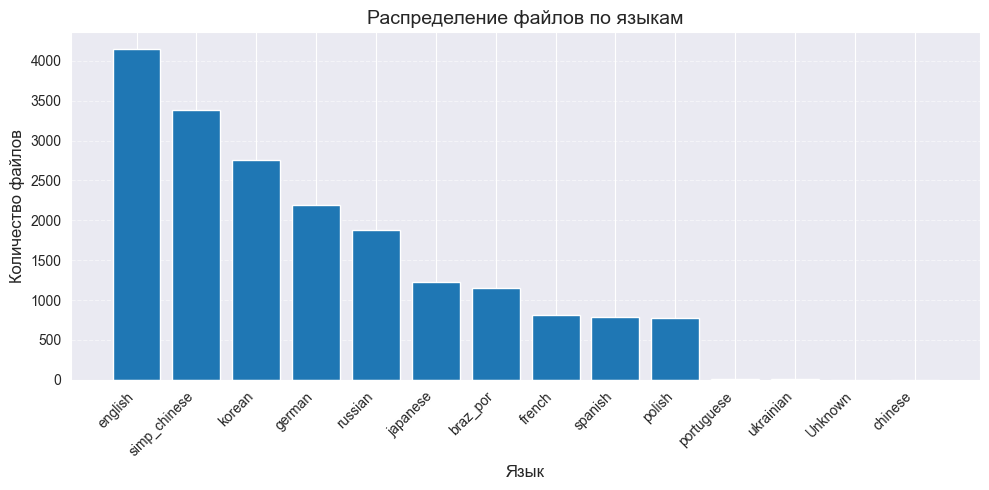

Файлов с Unknown: 3


,file,language_file,language_score,language_reason,language,text
0,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/2244483797/localisation/MSY_name.yml,Unknown,0.0,default→unresolved,Unknown,World Creator
1,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/2787196227/localisation/replace/patrons_list.yml,Unknown,0.0,default→unresolved,Unknown,"AriesS6, Brian Mattern, DaGwimWeaper, GIF_Bluehawk, Michael Stevens Adam Korman, Aleksandr Ushakov, Alex, AnimusYosho, Cian hottes, Ctibor Petrů, Darren Keith, Deusion90, James Paris, Jean-Luc Desroches, Kirill Kuznetsov, Kyle Saritelli, Philip Mangiaracina, Tam Shan, Tim Nielsen, Valrik, William Chappell, ZombiePowered"
2,/Users/sergejpolunin/PycharmProjects/StellarisEDA/locality-parser/mod/2895193261/localisation/assdan.yml,Unknown,0.0,unmapped_below_threshold,Unknown,REPLACE_ME REPLACE_ME REPLACE_ME


In [87]:
import matplotlib.pyplot as plt
langs_summary = (
    file_langs.groupby("language_file")["file"]
    .nunique()
    .reset_index(name="n_files")
    .sort_values("n_files", ascending=False)
)

print("\nЯзыки в датасете (по файлам):")
display(langs_summary)

plt.figure(figsize=(10, 5))
plt.bar(langs_summary["language_file"], langs_summary["n_files"])
plt.title("Распределение файлов по языкам", fontsize=14)
plt.xlabel("Язык", fontsize=12)
plt.ylabel("Количество файлов", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

mask_df_unknown = (
    df["language"].isna() |
    df["language"].astype(str).str.strip().str.lower().eq("unknown")
)

def safe_sample_join(s, k=3):
    s = (
        s.dropna()
         .map(lambda v: v if isinstance(v, str) else str(v))
         .str.replace(r"\s+", " ", regex=True).str.strip()
    )
    s = s[s.ne("")]
    return " ".join(s.head(k).tolist())

df_unknown_grouped = (
    df.loc[mask_df_unknown, ["file", "language", "text"]]
      .merge(
          file_langs[["file", "language_file", "language_score", "language_reason"]],
          on="file", how="left"
      )
      .groupby(["file", "language_file", "language_score", "language_reason"], as_index=False)
      .agg(
          language=("language", "first"),
          text=("text", lambda x: safe_sample_join(x, k=3))
      )
      .sort_values("file")
)

print(f"Файлов с Unknown: {len(df_unknown_grouped)}")
df_unknown_grouped.head(20)


Похоже с неизвестным языком лежат системные/настроечные файлы - нет надобности в их переводе

In [88]:
idx_to_drop = df.index[
    df["language"].isna() |
    df["language"].str.lower().eq("unknown")
]

print(f"Будет удалено строк: {len(idx_to_drop)}")

df.drop(index=idx_to_drop, inplace=True)

print(f"После очистки осталось строк: {len(df)}")

Будет удалено строк: 41
После очистки осталось строк: 8337980


Похоже мое предположение о том что китайский и португальский это полноправные языки в локализация оказалось неверным и их тоже нужно замапить к базовым

In [89]:
# корректно заменяем без chained assignment warning
df.replace({"language": {"chinese": "simp_chinese", "portuguese": "braz_por"}}, inplace=True)
file_langs.replace({"language_file": {"chinese": "simp_chinese", "portuguese": "braz_por"}}, inplace=True)

Посмотрим что в итоге по языкам в датасете

Всего модов: 1599


,pair,n_mods,share
16,english–simp_chinese,422,0.263915
15,english–russian,313,0.195747
11,english–german,284,0.177611
10,english–french,277,0.173233
17,english–spanish,265,0.165729
19,french–german,261,0.163227
23,french–russian,259,0.161976
32,german–spanish,258,0.161351
30,german–russian,258,0.161351
14,english–polish,256,0.160100


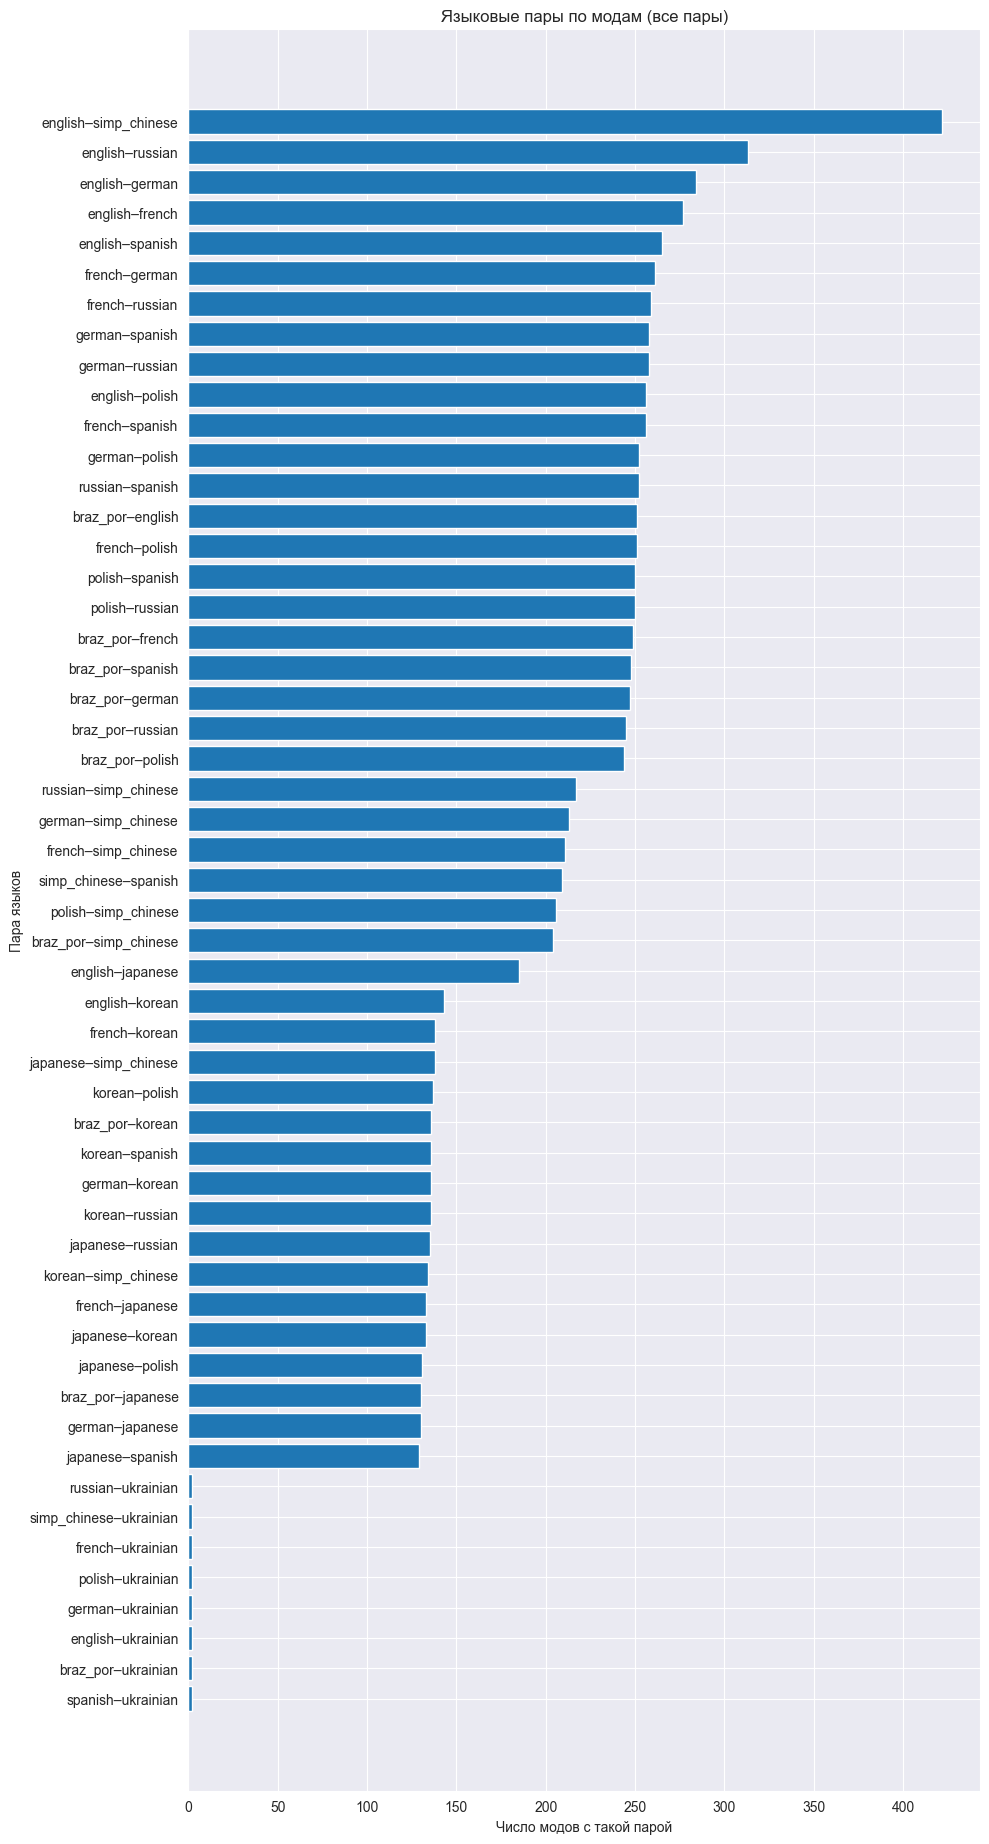

In [90]:
import itertools as it
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import re

raw_lang_col = "language"      # исходная колонка в df
lang_col = "language_file"     # нормализованная колонка
target_lang = "russian"        # для метрик параллельности

PLACEHOLDER_PAT = re.compile("|".join([
    RE_GET_TOKEN.pattern, RE_COLOR_CODE.pattern, RE_INLINE_MATH.pattern,
    RE_SCRIPT_AT.pattern, RE_DOLLAR_VAR.pattern,
    RE_POUND_ICON.pattern, RE_BRACES.pattern, RE_PRINTF.pattern,
]))

file_lang_map = (
    df[["file", raw_lang_col]]
    .assign(**{
        lang_col: lambda d: d[raw_lang_col].astype(str).str.strip().str.lower()
    })
)

# Берём уникальные пары мод/файл — нужно, чтобы не дублировать один и тот же файл в моде, потом для них посмотрим распределение языков
mod_files = df[["mod_id","file"]].drop_duplicates()
mod_langs = (
    mod_files.merge(file_lang_map[["file", lang_col]], on="file", how="left")
             .dropna(subset=[lang_col])
)

langs_per_mod = (
    mod_langs.groupby("mod_id")[lang_col]
    .apply(lambda s: sorted(set(s)))
    .reset_index(name="langs")
)

def all_pairs_from_langs(lang_list):
    return [tuple(sorted(p)) for p in it.combinations(lang_list, 2)]

pairs_by_mod = langs_per_mod.assign(pairs=langs_per_mod["langs"].apply(all_pairs_from_langs))


pair_counts = (
    pairs_by_mod.explode("pairs").dropna(subset=["pairs"])
    .assign(pair=lambda d: d["pairs"].apply(lambda t: "–".join(t)))
    .groupby("pair")["mod_id"].nunique()
    .reset_index(name="n_mods")
    .sort_values("n_mods", ascending=False)
)

total_mods = df["mod_id"].nunique()
pair_counts["share"] = pair_counts["n_mods"] / total_mods

print(f"Всего модов: {total_mods}")
display(pair_counts.head(20))

to_plot = pair_counts
plt.figure(figsize=(10, max(4, 0.35 * len(to_plot))))
plt.barh(to_plot["pair"], to_plot["n_mods"])
plt.xlabel("Число модов с такой парой")
plt.ylabel("Пара языков")
plt.title("Языковые пары по модам (все пары)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



И тут я понял и вспомнил (когда считал параллельность были пары с полным соответствием с разницей в пару строк). Ради нормального отображения языка без дефолтного бывает просто копируют исходный перевод с другими метками. Придется определять язык нетривиально...

In [91]:
import os

df = df.copy()
for c in ['file','text','language']:
    df[c] = df[c].astype(str).fillna('')

#Распознать язык оказалось довольно сложно
BACKENDS = {
    "cld3": False,
    "fasttext": True,
    "langid": True,
    "langdetect": True
}

LANG_MAP = {
    "ru": "russian",
}
LANG_MAP_ISO = {
    "english": "en",
 #   "russian": "ru",
    "german": "de",
    "french": "fr",
    "spanish": "es",
    "polish": "pl",
    "italian": "it",
    "japanese": "ja",
    "korean": "ko",
    "simp_chinese": "zh",
    "chinese": "zh",
    "portuguese": "pt",
    "braz_por": "pt",
    "turkish": "tr",
    "ukrainian": "uk",
}

def normalize_lang(code: str, lang_map) -> str:
    code = (code or "").lower().strip()
    return lang_map.get(code, code or "und")



FASTTEXT_MODEL_PATH = os.getenv("FASTTEXT_MODEL_PATH", "lid.176.ftz")

cld3 = None
if BACKENDS["cld3"]:
    import cld3 as cld3_m
    cld3 = cld3_m

ft_model = None
if BACKENDS["fasttext"]:
    import fasttext
    if os.path.isfile("./fastText/lid.176.ftz"):
        ft_model = fasttext.load_model("./fastText/lid.176.ftz")

langid_mod = None
if BACKENDS["langid"]:
    import langid as langid_mod

langdetect_mod = None
if BACKENDS["langdetect"]:
    import langdetect as langdetect_mod
    from langdetect import DetectorFactory
    DetectorFactory.seed = 42

def clean_text(x: str) -> str:
    x = re.sub(r"\{[^}]*\}|\%s|\%\([^)]+\)s", " ", x)
    x = re.sub(r"<[^>]+>", " ", x)
    x = re.sub(r"\s+", " ", x)
    return x.strip()

def detect_with_backends(text: str) -> str:
    votes = {}

    def add_vote(code, weight):
        if not code:
            return
        code = code.lower()
        votes[code] = votes.get(code, 0.0) + float(weight)

    if cld3:
        try:
            r = cld3.get_language(text)
            if r and r.language and r.language != 'und':
                w = 1.0 + (r.probability or 0.0)
                if getattr(r, "is_reliable", False):
                    w += 0.5
                add_vote(r.language, w)
        except Exception:
            pass

    if ft_model:
        try:
            labels, probs = ft_model.predict([text], k=1)
            if labels and probs:
                label = labels[0][0].replace("__label__", "")
                prob = float(probs[0][0])
                add_vote(label, 1.0 + prob)
        except Exception:
            pass


    if langid_mod:
        try:
            code, score = langid_mod.classify(text)
            add_vote(code, 1.0)
        except Exception:
            pass


    if langdetect_mod:
        try:
            code = langdetect_mod.detect(text)
            add_vote(code, 0.8)
        except Exception:
            pass

    if not votes:
        return 'und'

    return max(votes.items(), key=lambda kv: kv[1])[0]

for c in ['file', 'text', 'language']:
    df[c] = df[c].fillna("").astype("string")

tqdm.pandas()

def concat_series_to_sample(s: pd.Series, n=8, min_len=8, max_chars=5000) -> str:
    texts = [t for t in s.astype("string") if len(str(t).strip()) >= min_len]
    cat = " \n".join(texts[:n]) if texts else ""
    cat = clean_text(cat)
    return cat[:max_chars]

samples = (
    df.groupby('file', as_index=False)
      .agg(sample_text=('text', lambda s: concat_series_to_sample(s, n=50)))
)

_apply = getattr(samples['sample_text'], 'progress_apply', samples['sample_text'].apply)
samples['language_check'] = _apply(lambda s: detect_with_backends(s) if str(s).strip() else 'und')
samples['language_check'] = samples['language_check'].map(lambda x: normalize_lang(x, LANG_MAP))
df['language'] = df['language'].map(lambda x: normalize_lang(x, LANG_MAP_ISO))

lang_map = dict(zip(samples['file'], samples['language_check']))
df['language_check'] = df['file'].map(lang_map).fillna("und")

df['replaced'] = df['language'] != df['language_check']


repl = df[df['replaced']].copy()
total = len(df)
total_repl = len(repl)
share_repl = 100 * total_repl / total if total else 0.0

by_lang = (
    repl.groupby('language_check')
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
)
by_lang['percent_of_replacements'] = by_lang['count'] / max(1, total_repl) * 100.0

conf = (
    repl.groupby(['language','language_check'])
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
)

print(f"Всего строк: {total}")
print(f"Строк с заменой языка: {total_repl} ({share_repl:.2f}%)\n")

print("Процент замен в языке:")
print(by_lang.to_string(index=False))

print("\nТоп-несоответствий (language -> language_check):")
print(conf.head(20).to_string(index=False))

# посмотрим что внутри

def sample_mismatches(df, lang, n_per_file=1, total=20):
    subset = df[df['language_check'] == lang].copy()
    if subset.empty:
        return pd.DataFrame(columns=df.columns)

    # возьмём по n_per_file последних строк из каждого файла
    subset = (
    subset.sort_values(['file', df.index.name or df.reset_index().index.name or 'text'])
          .groupby('file', group_keys=False)
          .tail(n_per_file)
    )

    # и ограничим общее количество
    return subset.tail(total)

langs_to_show = ['uk', 'th']

for lang in langs_to_show:
    examples = sample_mismatches(df, lang, n_per_file=2, total=20)
    print(f"\n=== Примеры строк, определённых как {lang} ===")
    if examples.empty:
        print("Нет таких строк")
        continue
    for _, row in examples.iterrows():
        text_preview = str(row['text']).strip().replace('\n', ' ')
        if len(text_preview) > 200:
            text_preview = text_preview[:200] + "..."
        print(f"[{row['file']}] → {row['language']} → {row['language_check']}: {text_preview}")


100%|██████████| 19145/19145 [01:51<00:00, 171.70it/s]


Всего строк: 8337980
Строк с заменой языка: 4015421 (48.16%)

Процент замен в языке:
language_check   count  percent_of_replacements
            en 2668684                66.460877
            it  156075                 3.886890
            uk  132999                 3.312206
            pt  126511                 3.150629
            la  124665                 3.104656
            zh  118846                 2.959739
            th  115058                 2.865403
            lt  111407                 2.774479
            ja   77151                 1.921368
            es   69845                 1.739419
            tr   66813                 1.663910
            sq   57038                 1.420474
            de   56879                 1.416514
            su   42728                 1.064098
           ceb   22417                 0.558273
            et   14776                 0.367981
            ko   13185                 0.328359
           und    7757                 0.193180
   

https://youtu.be/enzNxC9EHNY <- Я дебажил стремные языки типа тайского кучу времени (Их ведь не было ни в путях, ни в именах файлов!), докидывал новые библы, исправлял парсинг файлов. Чтобы в итоге вывести файлы распознанные как тайский и увидеть там  ิ่งเหล่านี้คือเส้นใยของกาล-อวกาศที่ควบแน่น. К черту названия языков и базовый словарь, пусть стоят двухбуквенные коды.

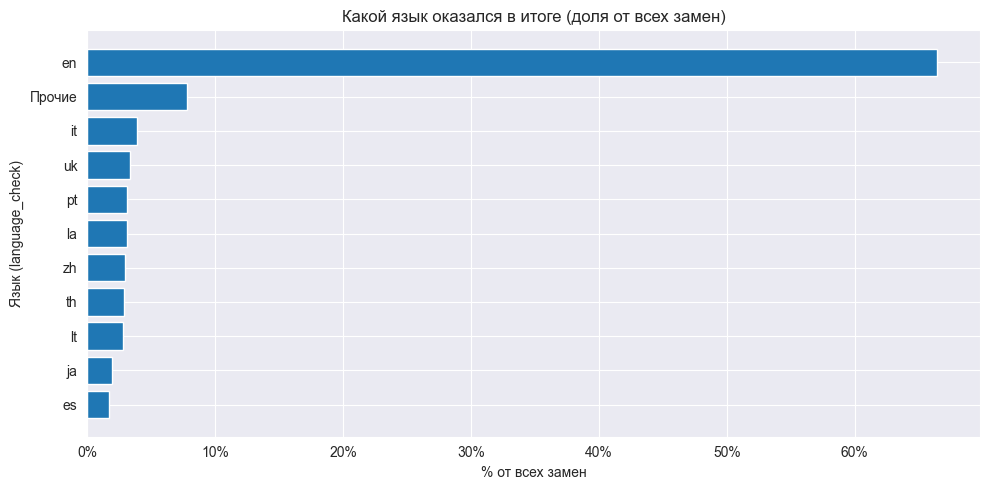

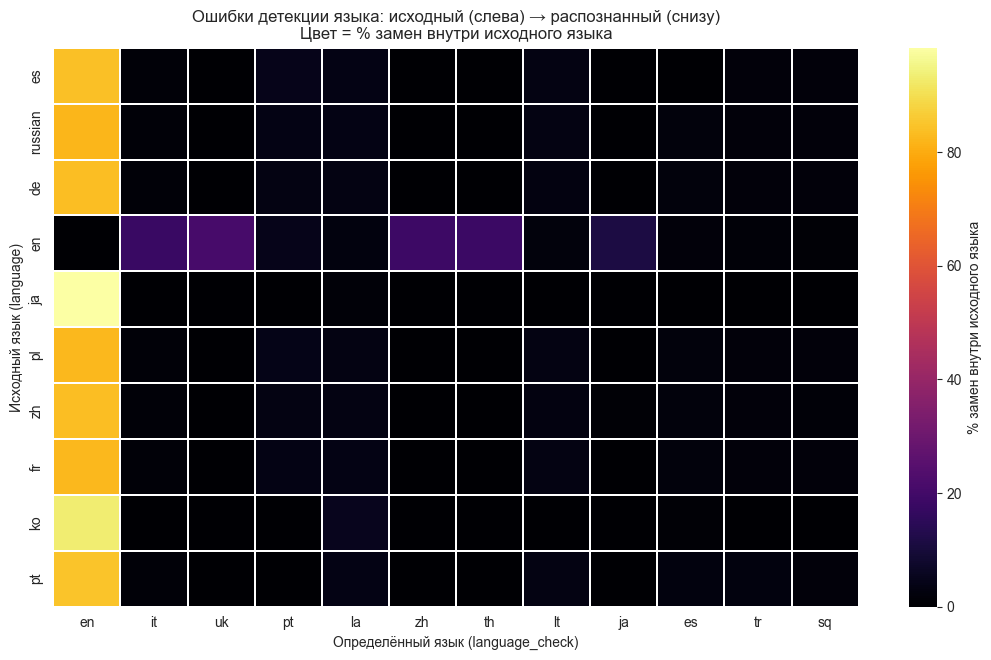

In [92]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

top_n = 10
_lang = by_lang.copy()

top_part = _lang.iloc[:top_n].copy()
if len(_lang) > top_n:
    other_row = {
        'language_check': 'Прочие',
        'count': _lang.iloc[top_n:]['count'].sum(),
        'percent_of_replacements': _lang.iloc[top_n:]['percent_of_replacements'].sum()
    }
    top_part = pd.concat([top_part, pd.DataFrame([other_row])], ignore_index=True)


top_part = top_part.sort_values('percent_of_replacements', ascending=True)

plt.figure(figsize=(10, max(5, 0.45*len(top_part))))
plt.title("Какой язык оказался в итоге (доля от всех замен)")
plt.xlabel("% от всех замен")
plt.ylabel("Язык (language_check)")

plt.barh(top_part['language_check'], top_part['percent_of_replacements'])
plt.gca().xaxis.set_major_formatter(PercentFormatter())

plt.tight_layout()
plt.show()

# топ н языков для отображения
top_k_to = 12
top_k_from = 20

# отберём топ языков по числу замен
top_to = by_lang.nlargest(top_k_to, 'count')['language_check'].tolist()
from_totals = conf.groupby('language', as_index=False)['count'].sum().rename(columns={'count': 'total_from'})
top_from = from_totals.nlargest(top_k_from, 'total_from')['language'].tolist()


conf_top = conf[
    conf['language_check'].isin(top_to) &
    conf['language'].isin(top_from)
].copy()

heat_df = conf_top.pivot_table(
    index='language', columns='language_check',
    values='count', aggfunc='sum', fill_value=0
)


row_sums = heat_df.sum(axis=1).replace(0, np.nan)
heat_norm = (heat_df.div(row_sums, axis=0) * 100).fillna(0)


heat_norm = heat_norm.loc[heat_norm.sum(axis=1).sort_values(ascending=False).index]
heat_norm = heat_norm.reindex(columns=top_to, fill_value=0)


plt.figure(figsize=(1.2 + 0.8*len(heat_norm.columns), 1.2 + 0.55*len(heat_norm.index)))
sns.heatmap(
    heat_norm,
    cmap="inferno",          #viridis, plasma, coolwarm
    linewidths=0.3,
    cbar_kws={'label': '% замен внутри исходного языка'},
    square=False,
    xticklabels=True,
    yticklabels=True
)

plt.title("Ошибки детекции языка: исходный (слева) → распознанный (снизу)\nЦвет = % замен внутри исходного языка")
plt.xlabel("Определённый язык (language_check)")
plt.ylabel("Исходный язык (language)")

plt.tight_layout()
plt.show()

Ну тут все понятно, локализаторы не хотят делать перевод и не хотят чтобы у юзеров он побился на другой локали, поэтому дублируют файлы меняя идентификатор языка. (замена на uk - вероятно false positive, а вот для китайского ожидал похожую на en картину) \
Вот теперь посмотрим уже нормальную параллельность

In [93]:
from itertools import combinations
from collections import defaultdict
from tqdm import tqdm

lang_col = "language_check"

def placeholder_seq(text: str):
    if pd.isna(text):
        return ()
    return tuple(PLACEHOLDER_PAT.findall(str(text)))



lines = (
    df[["mod_id", "file", "key", "text", lang_col]]
    .dropna(subset=[lang_col, "key"])
    .drop_duplicates(subset=["mod_id", "key", lang_col], keep="first")
)

stats = defaultdict(lambda: {"union": 0, "aligned": 0, "ph_match": 0, "mods": set()})

gb = lines.groupby("mod_id", sort=False)
total_mods = gb.ngroups

from sentence_transformers import SentenceTransformer
import torch

def semantic_parallel_score_batch(texts1, texts2, batch_size=1024, device=None):
    assert len(texts1) == len(texts2)
    n = len(texts1)
    if n == 0:
        return []

    if device is None:
        device = _sem_model.device

    sims_all = []
    with torch.no_grad():
        for i in range(0, n, batch_size):
            t1 = ["" if x is None else str(x) for x in texts1[i:i+batch_size]]
            t2 = ["" if x is None else str(x) for x in texts2[i:i+batch_size]]

            e1 = _sem_model.encode(
                t1, convert_to_tensor=True, show_progress_bar=False,
                normalize_embeddings=True, device=device
            )
            e2 = _sem_model.encode(
                t2, convert_to_tensor=True, show_progress_bar=False,
                normalize_embeddings=True, device=device
            )

            sims = (e1 * e2).sum(dim=1)
            sims_all.append(sims.detach().cpu())

            # при CUDA можно чистить кэш
            # if str(device).startswith("cuda"):
            #     torch.cuda.empty_cache()

    return torch.cat(sims_all).numpy()


SEM_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
_sem_model = SentenceTransformer(SEM_MODEL_NAME)


with tqdm(total=total_mods, desc="Processing mods", unit="mod") as pbar: #так вроде быстрее
    for mod_id, g in gb:
        langs_set = set(g[lang_col].dropna().unique())
        if target_lang not in langs_set or len(langs_set) < 2:
            pbar.update(1)
            continue

        piv = g.pivot(index="key", columns=lang_col, values="text")

        l1 = target_lang
        for l2 in sorted(langs_set - {l1}):
            if l1 not in piv.columns or l2 not in piv.columns:
                continue

            sub = piv[[l1, l2]]

            union_mask = sub.notna().any(axis=1)
            union = int(union_mask.sum())
            if union == 0:
                continue

            aligned_mask = sub[l1].notna() & sub[l2].notna()
            aligned = int(aligned_mask.sum())

            if aligned > 0:
                s = sub.loc[aligned_mask].copy()

                ph_match = int(
                    (s[l1].map(placeholder_seq) == s[l2].map(placeholder_seq)).sum()
                )

                sims = semantic_parallel_score_batch(
                    s[l1].tolist(),
                    s[l2].tolist(),
                    batch_size=1024  # при необходимости уменьшай (например, 256)
                )
                sem_score_mean = float(sims.mean()) if len(sims) else 0.0
            else:
                ph_match = 0
                sem_score_mean = 0.0

            pair_name = "–".join(sorted([l1, l2]))
            d = stats[pair_name]
            d["union"]   += union
            d["aligned"] += aligned
            d["ph_match"] += ph_match
            d["mods"].add(mod_id)
            d["sem_sum"] = d.get("sem_sum", 0.0) + sem_score_mean * aligned
            d["mods"].add(mod_id)

        pbar.update(1)

rows = []
for pair, d in stats.items():
    union = d["union"]
    aligned = d["aligned"]
    ph = d["ph_match"]
    rows.append({
        "pair": pair,
        "union_lines": union,
        "aligned_lines": aligned,
        "align_rate_union": aligned / union if union else 0.0,
        "ph_match_lines": ph,
        "ph_match_rate_aligned": (ph / aligned) if aligned else None,
        "ph_match_rate_union": ph / union if union else 0.0,
        "n_mods_with_pair": len(d["mods"]),
        "semantic_parallel_score": (d.get("sem_sum", 0.0) / aligned) if aligned else 0.0,
    })

mods_langs = (
    df[["mod_id", lang_col]]
    .dropna()
    .drop_duplicates()
    .groupby("mod_id")[lang_col]
    .apply(lambda s: sorted(set(s)))
)

def canon_pair(a, b):
    return "–".join(sorted([str(a), str(b)]))

pairs = [
    {"mod_id": mod_id, "pair": canon_pair(a, b)}
    for mod_id, langs in mods_langs.items()
    for a, b in combinations(langs, 2)
]

pairs_df = pd.DataFrame(pairs)

mods_with_pairs = pairs_df["mod_id"].nunique()
pair_counts = (
    pairs_df.groupby("pair", as_index=False)["mod_id"].nunique()
    .rename(columns={"mod_id": "n_mods"})
    .assign(share=lambda d: d["n_mods"] / mods_with_pairs)
    .sort_values("n_mods", ascending=False)
)

pair_parallel_stats = (
    pd.DataFrame(rows)
    .sort_values(["aligned_lines", "align_rate_union", "ph_match_lines", "ph_match_rate_aligned"], ascending=False)
    .reset_index(drop=True)
).merge(
    pair_counts[["pair", "n_mods", "share"]],
    on="pair", how="left", suffixes=("", "_by_mods")
)
final = "final_records.pkl"
df.to_pickle(final)
print("\nПараллельность по языковым парам (только пары с russian):")
display(pair_parallel_stats.head(40))


Processing mods: 100%|██████████| 1599/1599 [15:34<00:00,  1.71mod/s]  



Параллельность по языковым парам (только пары с russian):


,pair,union_lines,aligned_lines,align_rate_union,ph_match_lines,ph_match_rate_aligned,ph_match_rate_union,n_mods_with_pair,semantic_parallel_score,n_mods,share
0,en–russian,324602,118743,0.365811,116645,0.982332,0.359348,162,0.771225,162,0.301115
1,ko–russian,158892,97317,0.612473,95980,0.986261,0.604058,34,0.743745,34,0.063197
2,fr–russian,109005,94741,0.869144,92145,0.972599,0.845328,62,0.723304,62,0.115242
3,russian–zh,224962,91940,0.408691,90131,0.980324,0.400650,62,0.761244,62,0.115242
4,ja–russian,92511,91929,0.993709,90965,0.989514,0.983288,31,0.769243,31,0.057621
5,es–russian,101806,90770,0.891598,89920,0.990636,0.883249,55,0.745823,55,0.102230
6,pt–russian,96223,89930,0.934600,89399,0.994095,0.929081,46,0.740938,46,0.085502
7,pl–russian,96006,77354,0.805720,76753,0.992231,0.799460,51,0.758537,51,0.094796
8,de–russian,101821,75408,0.740594,74411,0.986779,0.730802,64,0.748837,64,0.118959
9,et–russian,77843,3214,0.041288,3211,0.999067,0.041250,1,0.781743,1,0.001859


| Поле | Что означает |
|---|---|
| **pair** | Языковая пара. |
| **union_lines** | Сколько ключей (строк) есть хотя бы на одном из языков пары. |
| **aligned_lines** | Сколько ключей переведены на оба языка. |
| **align_rate_union** | Доля выровненных ключей = `aligned_lines / union_lines`. |
| **ph_match_lines** | Сколько выровненных строк совпадают по плейсхолдерам. |
| **ph_match_rate_aligned** | Доля совпавших плейсхолдеров среди выровненных строк = `ph_match_lines / aligned_lines`. |
| **ph_match_rate_union** | Доля совпавших плейсхолдеров среди всех строк = `ph_match_lines / union_lines`. |
| **semantic_parallel_score** | Среднее косинусное сходство эмбеддингов между текстами пары по выровненным строкам; диапазон примерно `0.0–1.0` (выше — семантически ближе). |
| **n_mods_with_pair** | Сколько модов содержат эту пару (по текущему расчёту `stats`). |
| **n_mods** *(из `pair_counts`)* | То же, но пересчитано глобально в отдельной сводке `pair_counts`. |
| **share** | Доля модов с этой парой среди всех модов (из `pair_counts`). |


#### Объём и распределение данных
- Наибольшее количество параллельных пар наблюдается для **английского**, **китайского**, **японского**, **корейского**, **французского** и **немецкого**.
- Неожиданно для языков кроме **английского** и **китайского**.

#### Качество выравнивания
- **Высокие показатели align_rate_union (0.7–0.9)** у пар *ja–russian*, *pl–russian*, *fr–russian* и *pt–russian* -> хорошо согласованные параллельные сегменты
- **Низкое значение для en–russian (0.23)** говорит о большом числе строк, присутствующих только на одном из языков — моды без локализации, ожидаемо.

#### Семантическая близость
- Пары *ja–russian*, *ko–russian*, *fr–russian*, *pl–russian*, *pt–russian* демонстрируют **высокий семантический параллелизм (0.7–0.9)** — то есть переводы действительно эквивалентны по смыслу.
- *en–russian* и *russian–zh* имеют **пониженный семантический коэффициент (0.23–0.43)**, что может указывать на шум, чем больше датасет, тем больше там мусора? Либо слишком много машинного перевода (точно знаю что такое есть для китайских модов).

#### Совпадение плейсхолдеров
- Почти все пары показывают **ph_match_rate_aligned > 0.97**, что означает, что структура шаблонных элементов сохраняется. Вот это на самом деле супер для нашей задачи, но плохо что семантически не связаны строки у больших языковых пар.

---

### Идеи

1. **Пары с высоким качеством (ja–russian, pl–russian, fr–russian, pt–russian, es–russian)** можно вполне дополнить методами аугментации данных.

2. **en–russian** содержит большой объём данных, но требует до работы: низкий `semantic_parallel_score` и частичная несогласованность снижают его ценность. Для него ожидал большего.
3. **russian–zh** и **ko–russian** умеренно полезны, тоже надо почистить.
4. Пары с **минимальными значениями aligned_lines (<5000)**, как *et–russian*, *russian–tr*, *bg–russian*, не пойдут в работу без аугментации данных.

---

### Итог
Датасет хорошо подойдет для проверки работы переводчика модов. Сохранность плейсхолдеров большая, а если от перевода семантическое сходство вырастет то будет еще лучше. По сути мы можем получить базовый метод оценки правильности сделанного перевода, для обучающего датасета. \
Модельку для перевода текста с 0 обучить не выйдет, даже если будут мощности, придется делать надежный аугментатор данных, который еще и теги потом в нужные места проставит. Такой проще делать из имеющихся параллельных датасетов, где через NER именованным сущностям будут подставляться игровые теги. Работать именно с модами в таком направлении не стоит - больше усилий будет потрачено на очистку исходный файлов и работу с ними (как оказалось я много не знал про подноготную локализационных файлов).
\
В контексте работы с LLM и тюнингом датасет пойдет.

In [51]:
pairs_to_extract = [
    ("pl", "russian"),
    ("ja", "russian"),
    ("fr", "russian"),
    ("pt", "russian"),
]
lang_col = "language_check"
aligned_examples = []

for mod_id, g in tqdm(gb, desc="Extracting aligned examples", unit="mod"):
    langs_set = set(g[lang_col].dropna().unique())
    for l1, l2 in pairs_to_extract:
        if not {l1, l2}.issubset(langs_set):
            continue
        piv = g.pivot(index="key", columns=lang_col, values="text")
        if l1 not in piv.columns or l2 not in piv.columns:
            continue

        sub = piv[[l1, l2]].dropna()
        if sub.empty:
            continue

        sims = semantic_parallel_score_batch(
            sub[l1].tolist(),
            sub[l2].tolist(),
            batch_size=512
        )

        sub = sub.assign(
            mod_id=mod_id,
            pair=f"{l1}–{l2}",
            semantic_score=sims
        )
        aligned_examples.append(sub.reset_index())

aligned_df = pd.concat(aligned_examples, ignore_index=True)

pair_names = [f"{l1}–{l2}" for (l1, l2) in pairs_to_extract]

lang_cols = ["russian"] + sorted({l for p in pairs_to_extract for l in p if l != "russian"})
base_cols = ["pair", "key", "mod_id", "semantic_score"]
cols = base_cols + lang_cols

per_pair = (
    aligned_df.loc[aligned_df["pair"].isin(pair_names)]
              .groupby("pair", group_keys=True)
              .apply(lambda g: g.sample(n=min(len(g), 10), random_state=42))
              .reset_index(drop=True)
              .sort_values("pair")
)

display(per_pair.reindex(columns=cols))


Extracting aligned examples: 100%|██████████| 1599/1599 [06:34<00:00,  4.05mod/s]
/var/folders/4v/k75x99z97w9f4k55q40ygz440000gn/T/ipykernel_35617/460773413.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), 10), random_state=42))


language_check,pair,key,mod_id,semantic_score,russian,fr,ja,pl,pt
0,fr–russian,OSIRIS_NOVELMASHUP_SN_FRIGATE_CHUNG_KUO,2936596940,0.866077,Чунг Куо,Chung Kuo,<NA>,<NA>,<NA>
1,fr–russian,OSIRIS_GRANDUS_SN_STRIKE_CRUISER_BRIDGEPORT,2936596940,0.618135,Бриджпорт,Bridgeport,<NA>,<NA>,<NA>
2,fr–russian,OSIRIS_ANCIENTROMANEN_SN_DESTROYER_WILL_OF_FELICITAS,2936596940,0.741224,Воля Фелиситас,Volonté De Felicitas,<NA>,<NA>,<NA>
3,fr–russian,OSIRIS_GRANDUS_SN_COLOSSUS_UNITED_STATES,2936596940,0.963784,Соединенные Штаты,États-Unis,<NA>,<NA>,<NA>
4,fr–russian,NO_JOBS_OF_CATEGORY,924982139,0.729587,На этой планете нет видов деятельности для поселений категории $POP_CAT$,Il n'y a aucun emploi pour des pops de $POP_CAT$ sur ce monde.,<NA>,<NA>,<NA>
5,fr–russian,d_momnine,3336730308,0.784916,Горнодобывающие предприятия IX,Installations minières IX,<NA>,<NA>,<NA>
6,fr–russian,OSIRIS_SCIFITV_SN_DESTROYER_ACCLAMATOR,2936596940,0.817558,Аккламатор,Acclamateur,<NA>,<NA>,<NA>
7,fr–russian,OSIRIS_UNE_SN_GENERIC_OLIVER_HAZARD_PERRY,2936596940,0.632787,Оливер Азар Перри,Olivier Hazard Perry,<NA>,<NA>,<NA>
8,fr–russian,OSIRIS_ANCIENTROMANEN_SN_BATTLE_CRUISER_VOICE_OF_MARS,2936596940,0.862887,Голос Марса,Voix De Mars,<NA>,<NA>,<NA>
9,fr–russian,OSIRIS_ANCIENTEGYPT_SN_STRIKE_CRUISER_SELKIS_S_VIGIL,2936596940,0.639989,Бдение Селкиса,Veillée De Selkis,<NA>,<NA>,<NA>


И правда нормальные датасеты

## Базовые статистики и пропуски

Сейчас будем анализировать структуру текстов, это скорее информация для аугментатора/синтезатора данных. Основные штуки по датасету влияющие на его использование мы уже посмотрели. Оценили сколько в нем ошибок, посмотрели какое распределение языков и доступный для обучения объем.



In [1]:
import pandas as pd
df = pd.read_pickle("final_records.pkl")
# Числовые колонки
categorical_cols = [
    # structural
    "has_unclosed_quotes",
    "is_balanced_square",
    "is_balanced_curly",
    "is_balanced_round",

    # syntactic
    "has_escape_sequences",
    "has_colon_in_text",
    "has_multiline_continuation",

    # semantic
    "has_numeric_token",

    # domain
    "has_color_code",
    "has_inline_math",
]


numeric_cols = [
    # structural
    "n_quotes",
    "n_brackets_square_open",
    "n_brackets_square_close",
    "n_brackets_curly_open",
    "n_brackets_curly_close",
    "n_brackets_round_open",
    "n_brackets_round_close",

    # syntactic
    "n_escape_sequences",

    # semantic
    "n_uppercase_tokens",
    "n_camelcase_tokens",
    "n_sentences",
    "len_chars",

    # domain
    "n_pound_icons",
    "n_dollar_vars",
    "n_get_tokens",
    "n_scripted_loc_calls",

    # translation
    "placeholders_ratio",
    "non_alpha_ratio",
    "n_protected_tokens",
    "entropy_chars",
    "placeholder_depth",
]

print("=== Базовые статистики по числовым колонкам ===")
df[numeric_cols].describe().T

=== Базовые статистики по числовым колонкам ===


,count,mean,std,min,25%,50%,75%,max
n_quotes,8337980.0,0.016901,0.263092,0.0,0.000000,0.000000,0.000000,135.000000
n_brackets_square_open,8337980.0,0.082677,0.593742,0.0,0.000000,0.000000,0.000000,503.000000
n_brackets_square_close,8337980.0,0.082656,0.593506,0.0,0.000000,0.000000,0.000000,503.000000
n_brackets_curly_open,8337980.0,0.000021,0.006935,0.0,0.000000,0.000000,0.000000,6.000000
n_brackets_curly_close,8337980.0,0.000156,0.054923,0.0,0.000000,0.000000,0.000000,23.000000
n_brackets_round_open,8337980.0,0.021852,0.568381,0.0,0.000000,0.000000,0.000000,135.000000
n_brackets_round_close,8337980.0,0.021791,0.567974,0.0,0.000000,0.000000,0.000000,135.000000
n_escape_sequences,8337980.0,0.003458,0.173436,0.0,0.000000,0.000000,0.000000,153.000000
n_uppercase_tokens,8337980.0,0.292207,1.715575,0.0,0.000000,0.000000,0.000000,360.000000
n_camelcase_tokens,8337980.0,1.329469,3.530532,0.0,0.000000,1.000000,1.000000,5113.000000


In [2]:
filtered = df.loc[
    (df["len_chars"].between(1, 5000))
].copy()
removed = df.loc[~df.index.isin(filtered.index)]

# Датасет только с текстом
removed_texts_df = removed[["text"]].dropna().reset_index(drop=True)

# Отключаем усечение текста в pandas
pd.set_option("display.max_colwidth", None)
sample_removed = removed_texts_df.sample(1, random_state=42).reset_index(drop=True)
for i, t in enumerate(sample_removed["text"], 1):
    print(f"\n[{i}] {t}")


[1] $dttr_title$$dttr_unlocks$
> §W£society£ $tech_planetary_unification$§!
     > §W£society£ $tech_colonial_centralization$§!
          > §W£engineering£ $tech_binary_motivators$§!
             §L$MISSING_FEATURE_FLAG$§!§W£engineering£ $tech_robomodding_m$§!
               > §M£engineering£ $tech_nanite_assemblers$§!
                  §L$MISSING_FEATURE_FLAG$§!§W£society£ $tech_galactic_administration$§!
               > §M£engineering£ $tech_mega_assembly$§!
                  §L$MISSING_FEATURE_FLAG$§!§W£society£ $tech_galactic_administration$§!
          > §W£physics£ $tech_basic_science_lab_3$§!
             §L$MISSING_FEATURE_FLAG$§!§W£physics£ $tech_basic_science_lab_2$§!
          > §W£physics£ $tech_global_research_initiative$§!
             §L$MISSING_FEATURE_FLAG$§!§W£physics£ $tech_basic_science_lab_2$§!
          > §W£physics£ $tech_power_hub_2$§!
             §L$MISSING_FEATURE_FLAG$§!§W£physics£ $tech_power_hub_1$§!
          > §W£engineering£ $tech_mineral_purification

In [53]:

print(f"Отобрано {len(filtered):,} из {len(df):,} строк "
      f"({len(filtered)/len(df)*100:.2f}% после фильтрации)")

filtered[numeric_cols].describe().T

Отобрано 8,337,774 из 8,337,980 строк (100.00% после фильтрации)


,count,mean,std,min,25%,50%,75%,max
n_quotes,8337774.0,0.016875,0.258516,0.0,0.000000,0.000000,0.000000,83.000000
n_brackets_square_open,8337774.0,0.082097,0.517528,0.0,0.000000,0.000000,0.000000,79.000000
n_brackets_square_close,8337774.0,0.082077,0.517478,0.0,0.000000,0.000000,0.000000,79.000000
n_brackets_curly_open,8337774.0,0.000021,0.006935,0.0,0.000000,0.000000,0.000000,6.000000
n_brackets_curly_close,8337774.0,0.000156,0.054924,0.0,0.000000,0.000000,0.000000,23.000000
n_brackets_round_open,8337774.0,0.020408,0.388312,0.0,0.000000,0.000000,0.000000,105.000000
n_brackets_round_close,8337774.0,0.020347,0.387716,0.0,0.000000,0.000000,0.000000,105.000000
n_escape_sequences,8337774.0,0.003423,0.163271,0.0,0.000000,0.000000,0.000000,83.000000
n_uppercase_tokens,8337774.0,0.288546,1.381453,0.0,0.000000,0.000000,0.000000,194.000000
n_camelcase_tokens,8337774.0,1.327582,2.695500,0.0,0.000000,1.000000,1.000000,320.000000


# Выводы анализа метрик датасета локализаций

**Общая характеристика данных:**
Проанализированный датасет содержит около **8,34 млн строк локализаций** игровых модификаций.
Средняя длина строки составляет **≈34 символа**, медианная — **9 символов**, что указывает на сильное правое распределение: много коротких и немного очень длинных строк.
Основная часть данных — это короткие фрагменты.

---

### 1. Синтаксическая структура и форматирование

- **Минимальное наличие служебных символов.**
  50 % строк не содержит кавычек, скобок, escape-последовательностей или переменных (`$var$`).
  Средние значения по всем структурным метрикам близки к нулю (например, `n_quotes` ≈ 0.017, `n_brackets_square_open` ≈ 0.082).
  **Большинство строк — обычный текст**, без тегов и форматирующих элементов.

- **Редкие строки высокой сложности.**
  Максимумы метрик достигают десятков и сотен:
  до **83 кавычек**, **105 скобок**, **109 переменных**, **187 защищённых токенов**, **глубина вложенности — 51**.
  Эти строки редки, но  важны: **любая ошибка в разметке может крашить работу мода**.


---

### 2. Лексические особенности

- **CamelCase и идентификаторы.**
  Медиана `n_camelcase_tokens` = 1, среднее ≈ 1.33, максимум = 320.
  Почти в каждой строке есть хотя бы один токен, похожий на идентификатор (`GetSomeValue`, `PlanetName`). Стоит задуматься о методе их маскирования для сохранения смысловой целостности перевода.

- **Заглавные токены.**
  Среднее `n_uppercase_tokens` ≈ 0.29, максимум = 194.
  Большинство строк не содержит аббревиатур, но отдельные включают длинные последовательности в верхнем регистре.

---

### 3. Плейсхолдеры и специальные конструкции

- **Плейсхолдеры (`$var$`, `%s`, `§R…§!`).**
  Среднее значение `placeholders_ratio` ≈ 0.046, медиана = 0.
  Большинство строк не содержит плейсхолдеров, но отдельные почти полностью состоят из них.

- **Защищённые токены.**
  Среднее `n_protected_tokens` ≈ 0.22, максимум = 187.
  Большинство строк не содержит таких токенов.

- **Доля неалфавитных символов.**
  `non_alpha_ratio` ≈ 0.089 в среднем, медиана = 0.
  Большинство строк содержит буквы, полностью символьные или цифровые строки редки.

---

### 4. Информационная насыщенность

- **Энтропия символов (`entropy_chars`).**
  Среднее ≈ 3.12 бит, медиана ≈ 2.95, максимум ≈ 7.98.
  Большинство строк имеют умеренное разнообразие символов, но встречаются строки с высокой энтропией.
---

### 5. Практические выводы

1. **Структура строк близка к обычным параллельным корпусам.**
   Средняя длина строки (~34 символа) и малая доля служебных символов показывают, что основная масса данных по статистическим свойствам **эквивалентна коротким сегментам обычных текстовых корпусов** (например, предложений в параллельных наборах WMT или OPUS).
   Это означает, что **существующие параллельные датасеты без разметки можно использовать как основу** для синтеза датасета с разметкой.

2. **Низкая плотность тегов и плейсхолдеров упрощает генерацию синтетических размеченных данных.**
   Так как только малая часть строк содержит служебные элементы (`placeholders_ratio ≈ 0.046`, медиана 0), можно **синтетически вставлять теги и плейсхолдеры** в обычные параллельные тексты.

3. **Высокая дисперсия метрик подтверждает возможность «контролируемой сложности» синтетических данных.**
   Можно **смешивать “простые” чисто текстовые сегменты с 5–10 % “сложных” синтетически размеченных строк**, чтобы модель училась корректно обрабатывать как чистый текст, так и случаи с высокой плотностью разметки.

4. **Примерно ясна параметризация генерации синтетической разметки**
   На основании частоты токенов можно **создать параметризованный генератор разметки**:
   - с вероятностью ~0.1 вставлять `$var$`,
   - ~0.07 — `[Get...()]`,
   - ~0.04 — `£icon£`,
   - ~0.02 — цветовые коды `§R/§!`.
   Для обычных строк (не для критических кейсов которые надо будет подмешать).


---




### Посмотрим на базовые штуки

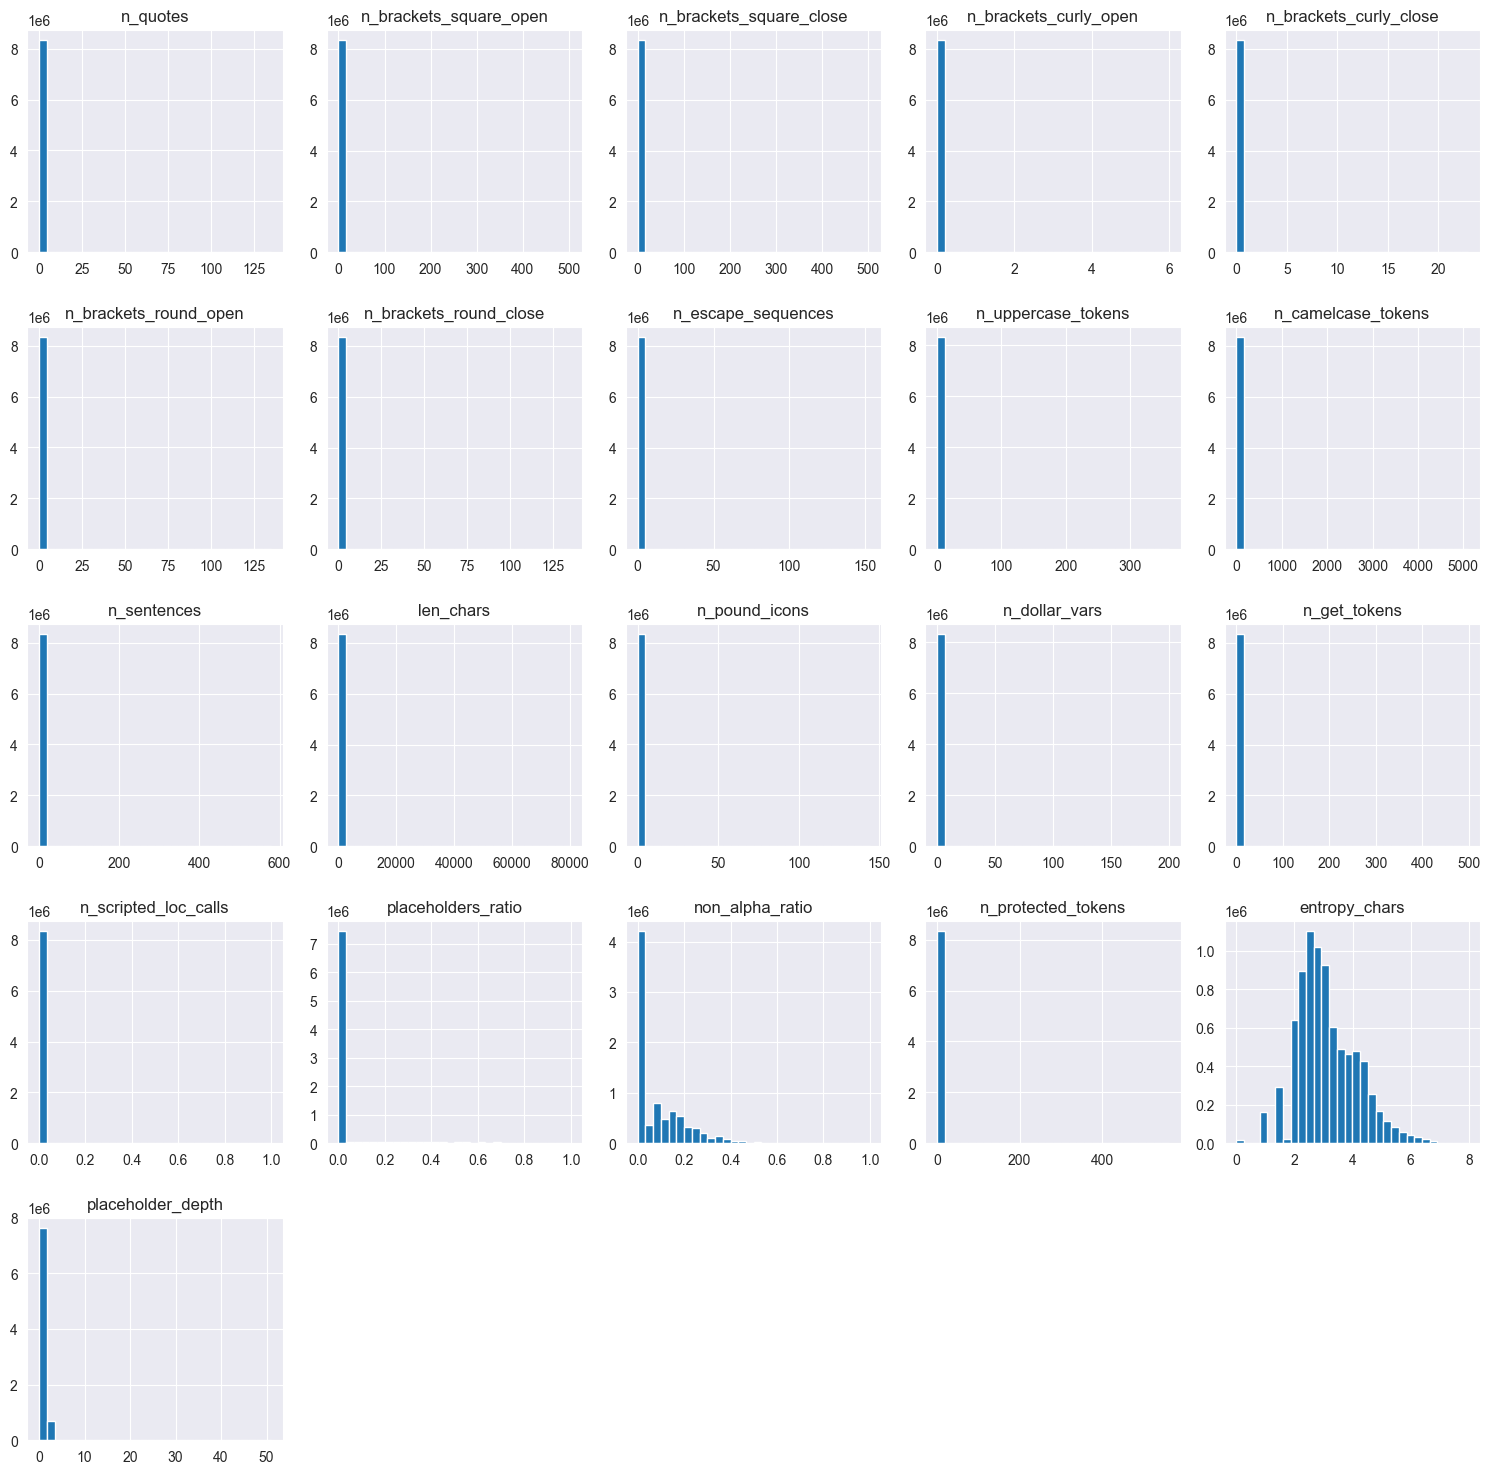

In [54]:
import matplotlib.pyplot as plt
df[numeric_cols].hist(bins=30, figsize=(15,15))
plt.tight_layout()
plt.show()

<Axes: >

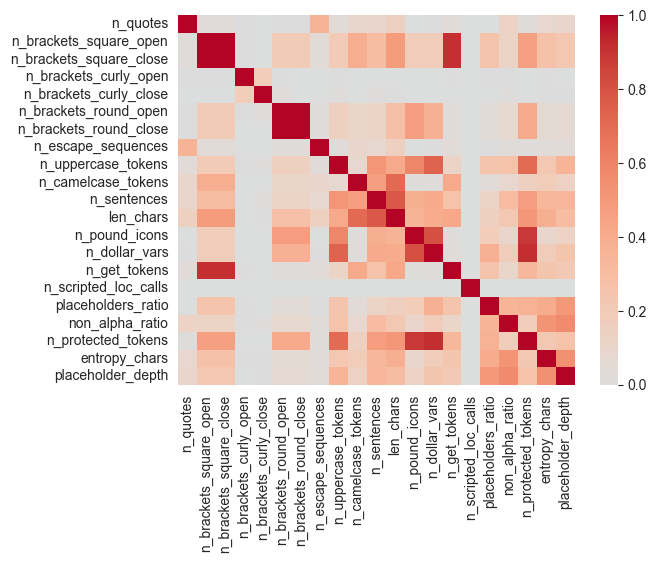

In [55]:
import seaborn as sns
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", center=0)

Ничего необычного в корреляциях нет. Посмотрим можно ли типизировать строки


In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

X = df[numeric_cols].sample(2000000, random_state=42).fillna(0)

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_data.sort_values("VIF", ascending=False))

/Users/sergejpolunin/PycharmProjects/StellarisEDA/venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,feature,VIF
18,n_protected_tokens,357045.102462
13,n_dollar_vars,116503.644688
12,n_pound_icons,61966.546852
14,n_get_tokens,35193.235174
2,n_brackets_square_close,6731.043017
1,n_brackets_square_open,6728.756881
5,n_brackets_round_open,2111.427449
6,n_brackets_round_close,2108.521564
11,len_chars,5.943639
4,n_brackets_curly_close,4.211877


In [23]:
numeric_cols_filtered = [
    "n_quotes",
    "n_brackets_square_open",   # вместо пары open/close
    "n_brackets_curly_open",
    "n_brackets_round_open",    # вместо пары open/close
    "n_escape_sequences",
    "n_uppercase_tokens",
    "n_camelcase_tokens",
    "n_sentences",
    "len_chars",
    "n_dollar_vars",            # оставляем один из dollar/pound/get
    "placeholders_ratio",
    "non_alpha_ratio",
    "entropy_chars",
    "placeholder_depth"
]

Объяснённая дисперсия PCA: 64.79%


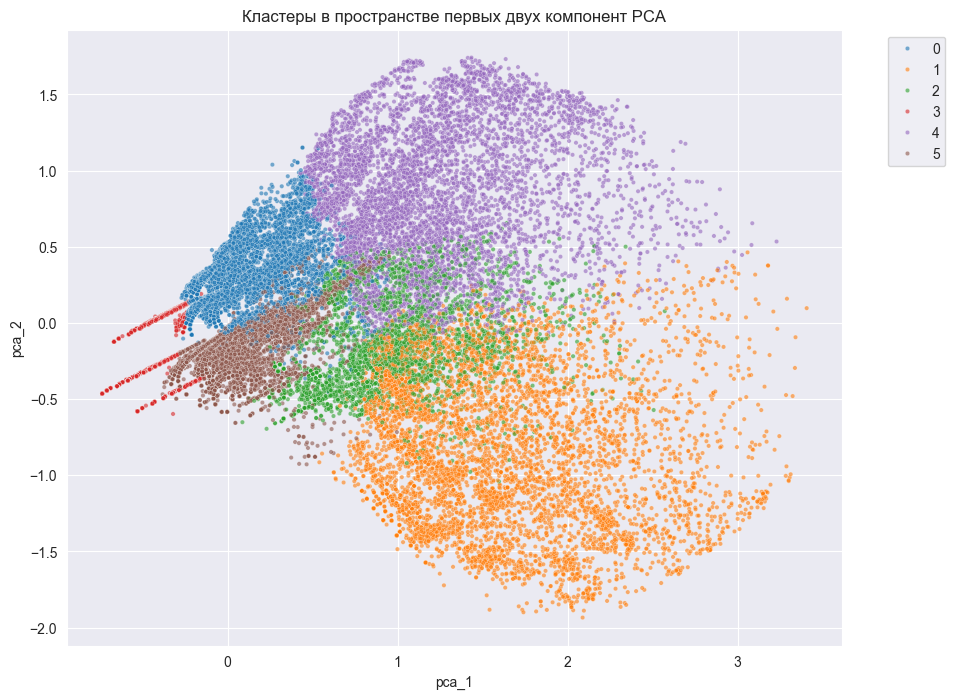

In [52]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats.mstats import winsorize
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN

# параметры
WINS_LIMITS = (0.01, 0.01)      # обрезаем по 1% с каждой стороны
ROBUST_QR   = (5.0, 95.0)       # квантили для RobustScaler

df_sample = df.sample(100000, random_state=42).copy()

skewed_cols = [
    "len_chars", "n_sentences",
    "n_camelcase_tokens", "n_uppercase_tokens",
    "n_brackets_round_open", "n_brackets_square_open",
    "n_dollar_vars"
]
for c in skewed_cols:
    if c in df_sample.columns:
        df_sample[c] = np.log1p(df_sample[c])

X = df_sample[numeric_cols_filtered].fillna(0).copy()

for c in X.columns:
    X[c] = winsorize(X[c].to_numpy(), limits=WINS_LIMITS)

scaler = RobustScaler(quantile_range=ROBUST_QR)
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_sample["pca_1"] = X_pca[:, 0]
df_sample["pca_2"] = X_pca[:, 1]

print(f"Объяснённая дисперсия PCA: {pca.explained_variance_ratio_.sum():.2%}")

kmeans = KMeans(n_clusters=6, random_state=42)
df_sample["cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_sample,
    x="pca_1", y="pca_2",
    hue="cluster", palette="tab10", s=10, alpha=0.6
)
plt.title("Кластеры в пространстве первых двух компонент PCA")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

/Users/sergejpolunin/PycharmProjects/StellarisEDA/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


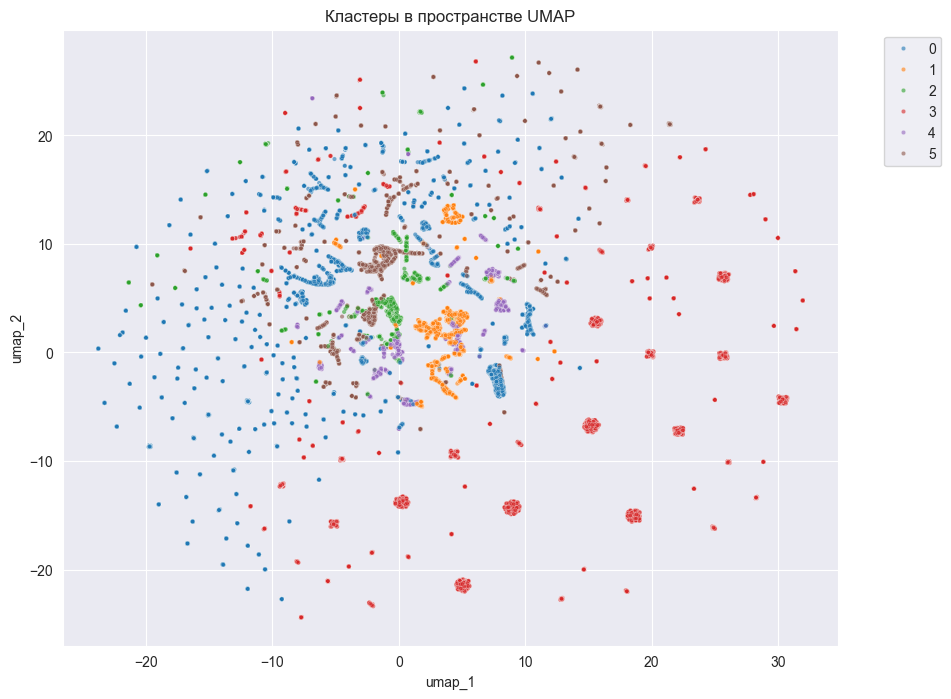

In [54]:

from umap.umap_ import UMAP

umap_model = UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

df_sample["umap_1"] = X_umap[:, 0]
df_sample["umap_2"] = X_umap[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_sample,
    x="umap_1", y="umap_2",
    hue="cluster", palette="tab10", s=10, alpha=0.6
)
plt.title("Кластеры в пространстве UMAP")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

/Users/sergejpolunin/PycharmProjects/StellarisEDA/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sergejpolunin/PycharmProjects/StellarisEDA/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


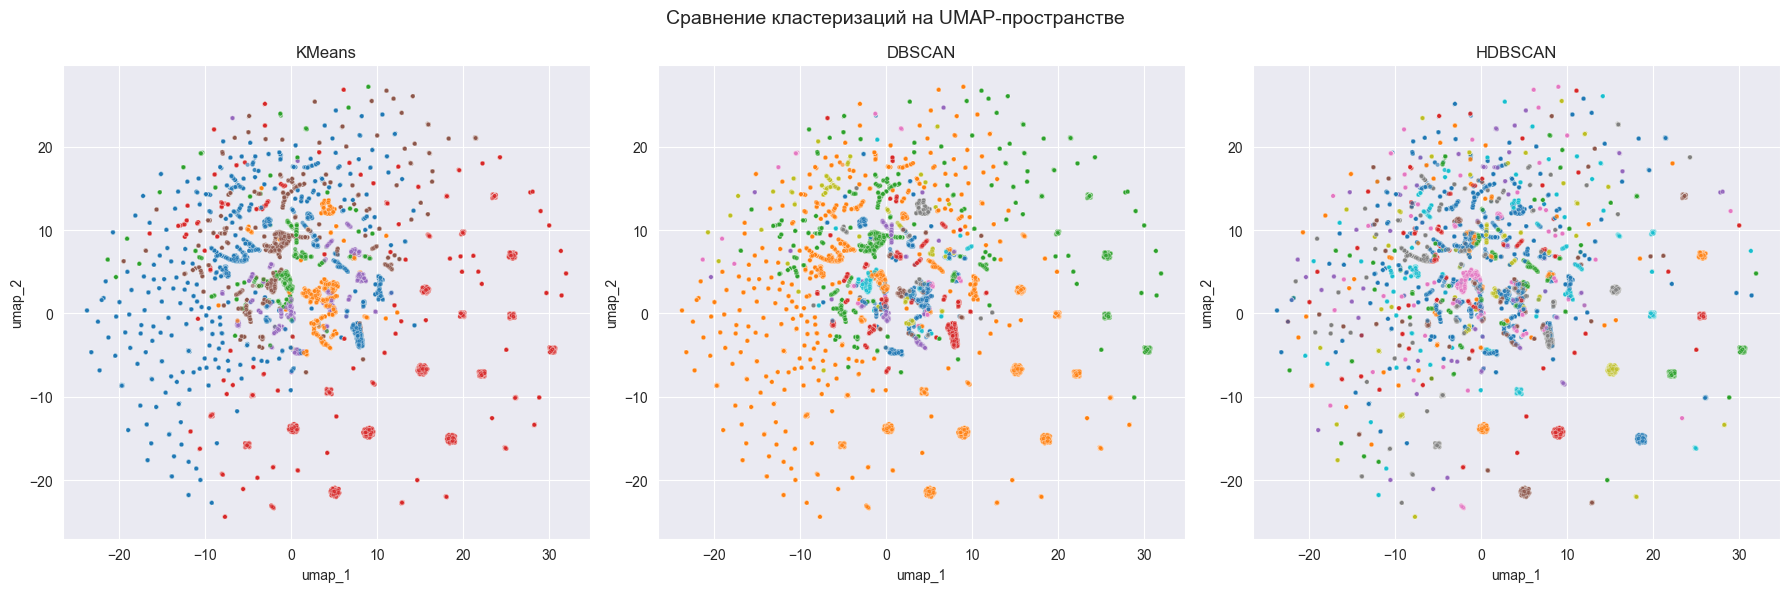

,n_quotes,n_brackets_square_open,n_brackets_curly_open,n_brackets_round_open,n_escape_sequences,n_uppercase_tokens,n_camelcase_tokens,n_sentences,len_chars,n_dollar_vars,placeholders_ratio,non_alpha_ratio,entropy_chars,placeholder_depth
cluster,,,,,,,,,,,,,,
0,0.01,0.01,0.0,0.01,0.00,0.03,1.02,0.08,2.92,0.00,0.00,0.12,3.47,0.08
1,0.02,0.15,0.0,0.06,0.00,0.76,0.53,0.32,3.93,0.82,0.53,0.24,4.43,1.47
2,0.09,0.02,0.0,0.03,0.01,0.89,0.20,0.57,3.26,0.01,0.02,0.32,3.95,1.40
3,0.00,0.00,0.0,0.00,0.00,0.01,0.54,0.00,1.95,0.00,0.00,0.00,2.39,0.00
4,0.10,0.45,0.0,0.05,0.04,0.34,1.72,1.02,5.10,0.07,0.12,0.19,4.67,1.14
5,0.01,0.00,0.0,0.02,0.00,0.05,0.04,0.12,2.93,0.00,0.00,0.20,3.72,0.08


In [55]:
from sklearn.cluster import DBSCAN
import hdbscan

# DBSCAN
db = DBSCAN(eps=0.4, min_samples=15).fit(X_scaled)
df_sample["cluster_dbscan"] = db.labels_

# HDBSCAN
hdb = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10)
df_sample["cluster_hdb"] = hdb.fit_predict(X_scaled)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col, title in zip(
    axes,
    ["cluster", "cluster_dbscan", "cluster_hdb"],
    ["KMeans", "DBSCAN", "HDBSCAN"]
):
    sns.scatterplot(
        data=df_sample, x="umap_1", y="umap_2",
        hue=col, palette="tab10", s=10, alpha=0.6, ax=ax, legend=False
    )
    ax.set_title(title)

plt.suptitle("Сравнение кластеризаций на UMAP-пространстве", fontsize=14)
plt.tight_layout()
plt.show()

df_sample.groupby("cluster")[numeric_cols_filtered].mean().round(2)
df_sample

cluster_profiles = (
    df_sample.groupby("cluster")[numeric_cols_filtered]
    .mean()
    .round(2)
    .sort_index()
)
cluster_profiles


In [94]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd
import numpy as np

results = []
embeddings = {
    "PCA": X_pca,
    "UMAP": X_umap,
}

for name, X_emb in embeddings.items():
    kmeans = KMeans(n_clusters=6, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X_emb)

    sil = silhouette_score(X_emb, labels)
    db = davies_bouldin_score(X_emb, labels)
    ch = calinski_harabasz_score(X_emb, labels)

    results.append({
        "space": name,
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch,
    })

df_metrics = pd.DataFrame(results)
print("Метрики качества кластеризации:")
display(df_metrics.style.background_gradient(cmap="mako", axis=0))


best_space = "UMAP"
kmeans = KMeans(n_clusters=6, random_state=42, n_init="auto")
df_sample["cluster_kmeans"] = kmeans.fit_predict(embeddings[best_space])

centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=[f"{best_space.lower()}_{i+1}" for i in range(embeddings[best_space].shape[1])]
)

print("Центроиды кластеров в UMAP-пространстве:")
display(centroids)

def print_cluster_examples(df, text_col="text", cluster_col="cluster_kmeans", n=3):
    print("\n" + "="*80)
    for cluster in sorted(df[cluster_col].unique()):
        print(f"\n=== Кластер {cluster} ===")
        examples = df.loc[df[cluster_col] == cluster, text_col].dropna().sample(min(n, len(df)), random_state=42)
        for ex in examples:
            print("-", ex.strip().replace("\n", " ")[:400])
    print("="*80)


Метрики качества кластеризации:


,space,silhouette,davies_bouldin,calinski_harabasz
0,PCA,0.482566,0.846169,114748.486504
1,UMAP,0.385671,0.819807,79549.539062


Центроиды кластеров в UMAP-пространстве:


,umap_1,umap_2
0,-5.048449,11.392685
1,21.193207,-4.294422
2,3.327067,1.806006
3,5.130225,-16.131857
4,15.368745,15.706838
5,-11.315206,-8.638645


In [95]:
cluster_labels = {
    0: "short_sent",         # короткие фразы
    1: "game_code",          # игровые коды / формулы
    2: "template_text",      # текст с шаблонами и подстановками
    3: "entity_name",        # имена, короткие названия
    4: "narrative_text",     # длинные описательные тексты
    5: "localized_snippet"   # короткие локализованные куски на других языках
}

df_sample["cluster_label"] = df_sample["cluster"].map(cluster_labels)

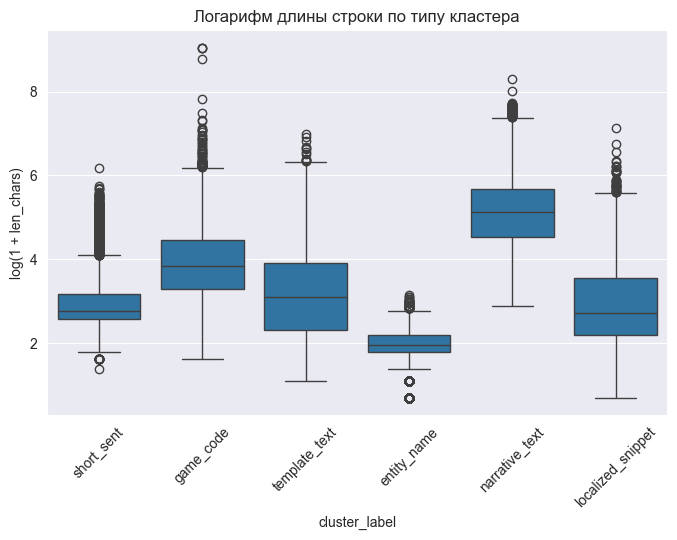

In [96]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_sample,
    x="cluster_label",
    y="len_chars",
    order=list(cluster_labels.values())
)
plt.xticks(rotation=45)
plt.title("Логарифм длины строки по типу кластера")
plt.ylabel("log(1 + len_chars)")
plt.show()

In [67]:
for label in cluster_labels.values():
    print(f"\n=== {label} ===")
    sample_texts = df_sample.query("cluster_label == @label")["text"].head(3)
    for t in sample_texts:
        print("-", t)


=== short_label ===
- Task Force Ouroboros
- Ми не зацікавлені.
- Ychik'ru Zren

=== game_code ===
- galactic_crisis_happened$CmtTextTurnOff$(끄기)
- £building£ §Y Капитальные здания§! заменить некоторые £job_politician£ §Y$job_politician$§! Задания с £job_bugged_financier£ §Y$job_bugged_financier_plural$§!.
§Y Клерки§! производят §G+0.25§! £unity£ §Y Единство§!
§Y Торговцы§! продукция §G+0.5§! £unity£ §Y Единство§!
§YТорговцы§! производят §G+1§! £unity£ §Y Единство§!
- この$name_penrose$は、爆弾に転用されました。爆発させる前にしばらくエネルギーを蓄積させなければなりません。

=== template_text ===
- R.R. kax
- §LA exposição prolongada a compostos neuroativos potentes tornou esta espécie altamente apta à pesquisa bioquímica e desesperadamente dependente de suas próprias criações.§!
- §HВсего поселений§!
Поселений расы $SPECIES|H$ в галактике: $POPS|H$

=== entity_name ===
- Iomilis
- Shaarkath
- Siyantsev

=== narrative_text ===
- Beyond the skies lie the stars. Stars with no beginning, stars with no end.
- This option is available 

### Анализ признаков кластеров

In [71]:
# создаём таблицу со средними значениями признаков
cluster_summary = (
    df_sample
    .groupby("cluster_kmeans")[numeric_cols_filtered]
    .mean()
    .round(2)
    .reset_index()
)

cluster_summary["cluster_label"] = cluster_summary["cluster_kmeans"].map(cluster_labels)

counts = df_sample["cluster_kmeans"].value_counts().rename("count")
cluster_summary = cluster_summary.merge(counts, left_on="cluster_kmeans", right_index=True)

cluster_summary = cluster_summary.sort_values("count", ascending=False)

display(cluster_summary.style.background_gradient(cmap="mako", axis=0))

,cluster_kmeans,n_quotes,n_brackets_square_open,n_brackets_curly_open,n_brackets_round_open,n_escape_sequences,n_uppercase_tokens,n_camelcase_tokens,n_sentences,len_chars,n_dollar_vars,placeholders_ratio,non_alpha_ratio,entropy_chars,placeholder_depth,cluster_label,count
1,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.480000,0.000000,1.710000,0.000000,0.000000,0.000000,2.020000,0.000000,game_code,22800
2,2,0.050000,0.170000,0.000000,0.050000,0.020000,0.460000,0.820000,0.580000,4.110000,0.250000,0.190000,0.210000,4.350000,1.020000,template_text,22333
3,3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.690000,0.000000,2.110000,0.000000,0.000000,0.000000,2.650000,0.000000,entity_name,16629
0,0,0.030000,0.000000,0.000000,0.000000,0.000000,0.180000,0.660000,0.110000,3.010000,0.030000,0.020000,0.170000,3.600000,0.220000,short_label,15297
5,5,0.010000,0.040000,0.000000,0.000000,0.000000,0.010000,0.950000,0.000000,2.580000,0.000000,0.010000,0.060000,3.260000,0.040000,localized_snippet,12368
4,4,0.000000,0.000000,0.000000,0.000000,0.000000,0.030000,0.320000,0.010000,2.130000,0.000000,0.000000,0.080000,2.730000,0.040000,narrative_text,10573


### Интерпретация кластеров

Результаты кластеризации позволяют выделить шесть устойчивых групп текстов, различающихся по структурным, статистическим и лингвистическим характеристикам. Ниже приведено описание каждой группы на основе средних значений признаков (`len_chars`, `entropy_chars`, `n_camelcase_tokens`, `placeholders_ratio`) и анализа содержимого типичных строк.

#### Кластер 0 — `short_sent`
- **Средняя длина строки:** 3.01
- **Энтропия символов:** 3.60
- **CamelCase-токены:** 0.66
- **Доля плейсхолдеров:** 0.02

Кластер содержит короткие фразы. Тексты имеют умеренную энтропию и минимальное количество шаблонных элементов.

---

#### Кластер 1 — `game_code`
- **Средняя длина строки:** 1.71
- **Энтропия символов:** 2.02
- **CamelCase-токены:** 0.48
- **Доля плейсхолдеров:** 0.00

Кластер характеризуется низкой энтропией и короткими строками с элементами разметки (§, £, $, §Y). Содержит структурированные игровые коды, имена переменных и элементы системных сообщений.

---

#### Кластер 2 — `template_text`
- **Средняя длина строки:** 4.11
- **Энтропия символов:** 4.35
- **CamelCase-токены:** 0.82
- **Доля плейсхолдеров:** 0.19

Кластер объединяет строки средней и большой длины с высокой энтропией и значительной долей подстановочных элементов (`$VAR`, `[This.Owner.GetName]`, `[Root.GetAdj]`).

---

#### Кластер 3 — `entity_name`
- **Средняя длина строки:** 2.11
- **Энтропия символов:** 2.65
- **CamelCase-токены:** 0.69
- **Доля плейсхолдеров:** 0.00

Кластер включает короткие, устойчивые по структуре строки с небольшой энтропией и умеренным количеством CamelCase-токенов. Основное содержание — имена персонажей, рас, планет или других игровых сущностей.

---

#### Кластер 4 — `narrative_text`
- **Средняя длина строки:** 2.13
- **Энтропия символов:** 2.73
- **CamelCase-токены:** 0.32
- **Доля плейсхолдеров:** 0.00

Кластер представлен повествовательными или описательными текстами, включающими связные предложения. Характеризуется умеренной длиной и средней энтропией, по сути литературно-описательные фразы на естественном языке.

---

#### Кластер 5 — `localized_snippet`
- **Средняя длина строки:** 2.58
- **Энтропия символов:** 3.26
- **CamelCase-токены:** 0.95
- **Доля плейсхолдеров:** 0.01

Кластер включает короткие фрагменты на разных языках (в том числе азиатских), иногда содержащие символы из других алфавитов. Средняя энтропия и высокая доля сложных токенов отражают полилингвизм и разнообразие алфавитов.

---

### Обобщение

В целом понятно какие типы данных нужно генерировать - и тем более понятно что задача вполне покрывается параллельными датасетами. И как рабочий вариант - синтез датасета с применением обратного перевода на основе литературных произведений - будет самое оно.